# Flight Delay Prediction Model Data Processing and Handling
This file will contain the sources, explanations and justifications for all the data used in training this project's prediction model. This file's code aims to gather relevant data from multiple sources and process it all to create finalized, completed files that are ready for modeling usage.

There are three categories of data that we will process in this file: flight on-time performance, weather data, and air traffic data, which I will combine into one final file to train the model on. All the methodology and preprocessing will be organized based on the file for which it was done.

## 1- Flight On-Time Report
### Description:
This file will be the focal point of our model's training, and all other datasets will be revolved around the data in this file. This file will contain nearly all the departing flights on Delta, United, American, Southwest, Alaskan, JetBlue, Spirit and Frontier out of Atlanta-Hartsfield, Denver, Los Angeles, Chicago-O'Hare and New York-JFK from 01/01/2024 to 12/31/2024. <br>
* The airlines above were chosen because together, they control a combined [87%](https://www.transtats.bts.gov) of the domestic airline market share in the United States. <br>
* Those five airports were picked since they are in the list of the ten busiest airports in the United States by passengers. The reason I did not pick the highest five directly is because I tried to choosing airports that are geographically far apart with varying weather conditions, so that the model can be trained in most conditions across the United States.
* I chose the datas to be limited to one year to account for the weather of all four seasons, and so it is as far from the effects of COVID-19 as possible.

### Source:
The data was gathered from the Bureau of Transportation Statistics from their [online tool](https://www.transtats.bts.gov/ontime/departures.aspx) that allows you to gather data on all the flights leaving out of an airport from a specific airline. I manually searched and saved the data for every airline at every airport from the ones mentioned above, and organized them into folders which will be available with this project.
<br>

The files are named in the format of XXX-XX, where the first three letters are the departing airport's IATA code, followed by the airline's IATA code. For example, ATL-DL would be the file containing all Delta flights departing from Atlanta.

##### Each of the following datasets contains the following columns:

- Carrier Code:<br>
The airline that's flying the flight

- Date (MM/DD/YYYY):<br>
The date the flight took place
- Flight Number:<br>
The number of the flight, which is unique only on an airline-by-airline basis
- Tail  Number: <br>
The plane that flew the route
- Destination Airport: <br>
The end destination of the flight
- Scheduled departure time: <br>
The time the plane is scheduled to take off, in 24H format
- Actual departure time: <br>
The time the plane is actually took off, in 24H format
- Departure delay (Minutes): <br>
The difference between the scheduled and actual take-off, which will be negative if the flight left early
- Delay Carrier (Minutes): <br>
The minutes of delay caused by carrier issues
- Delay Weather (Minutes): <br>
The minutes of delay caused by weather issues
- Delay National Air System (Minutes): <br>
The minutes of delay caused by issues with the National Air System
- Delay Security (Minutes): <br>
The minutes of delay caused by security issues
- Delay Late Aircraft (Minutes): <br>
The minutes of delay caused by the aircraft arriving late from its previous leg

##  A- Data Collection

Firstly, we're going to combine every airport's flights into one big CSV for each airport. Then, we will create one big CSV for all the flights across all the airports, which will be used for our modeling. All data processing will be done in the final CSV unless it is something that needs to be filtered by the airport.
 <br>

 All functions or variables that will span multiple airports will be declared after the imports.

In [2]:
#imports

# basics
import math
import numpy as np
import pandas as pd
from datetime import datetime
import glob
import warnings
from IPython.display import display

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# data analysis
import pingouin as pg
# from dataprep.eda import plot_correlation
from sklearn.preprocessing import LabelEncoder

# computation
from scipy.stats import kurtosis ,spearmanr, pointbiserialr, chi2_contingency
#from scipy.stats.mstats import winsorize

# modeling

In [3]:
# initializing variables
all_airports_df = pd.DataFrame()

In [4]:
# initializing functions

# turn an integer time into a cyclical time
def make_time_cyclical(current_duration, kind: str, func=None):
    cos_cyclical_current_duration = 0
    sin_cyclical_current_duration = 0
    allowed_kinds = ['month','hour','minute','day29','day30','day31','weekday','year']
    if kind not in allowed_kinds:
        raise ValueError('Invalid kind')
    match kind:
        case 'month':
            sin_cyclical_current_duration = np.sin(2 * math.pi * (current_duration-1)/12)
            cos_cyclical_current_duration = np.cos(2 * math.pi * (current_duration-1)/12)
        case 'hour':
            sin_cyclical_current_duration = np.sin(2 * math.pi * current_duration/24)
            cos_cyclical_current_duration = np.cos(2 * math.pi * current_duration/24)
        case 'minute':
            sin_cyclical_current_duration = np.sin(2 * math.pi * current_duration/60)
            cos_cyclical_current_duration = np.cos(2 * math.pi * current_duration/60)
        case 'day29':
            sin_cyclical_current_duration = np.sin(2 * math.pi * (current_duration-1)/29)
            cos_cyclical_current_duration = np.cos(2 * math.pi * (current_duration-1)/29)
        case 'day30':
            sin_cyclical_current_duration = np.sin(2 * math.pi * (current_duration-1)/30)
            cos_cyclical_current_duration = np.cos(2 * math.pi * (current_duration-1)/30)
        case 'day31':
            sin_cyclical_current_duration = np.sin(2 * math.pi * (current_duration-1)/31)
            cos_cyclical_current_duration = np.cos(2 * math.pi * (current_duration-1)/31)
        case 'weekday':
            sin_cyclical_current_duration = np.sin(2 * math.pi * current_duration/7)
            cos_cyclical_current_duration = np.cos(2 * math.pi * current_duration/7)
        case 'year':
            sin_cyclical_current_duration = np.sin(2 * math.pi * current_duration/365)
            cos_cyclical_current_duration = np.cos(2 * math.pi * current_duration/365)
    if func == 'sin':
        return sin_cyclical_current_duration
    if func == 'cos':
        return cos_cyclical_current_duration
    return sin_cyclical_current_duration, cos_cyclical_current_duration

#  function to calculate epsilon squared
# borrowed from substack overflow
def epsilon_squared(h, k, n):
    return (h - k + 1) / (n - k)

# function to calculate epsilon squared
# borrowed from geeks for geeks
def cramers_v(x, y):
    # Create a contingency table
    current_contingency_table = pd.crosstab(x, y)
    chi2_stat, p_val, dof, expected = chi2_contingency(current_contingency_table)

    # Calculate Cramer's V
    n = current_contingency_table.sum().sum()
    phi2 = chi2_stat / n
    r, k = current_contingency_table.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    k_corr = k - (k - 1) * (k - 2) / (n - 1)
    r_corr = r - (r - 1) * (r - 2) / (n - 1)
    v = np.sqrt(phi2corr / min(k_corr - 1, r_corr - 1))

    return v

### Airport 1: Atlanta-Hartsfield (ATL)

In [5]:
# creating a list containing the file location of each csv
alt_files_folder_location = '/flight_delay_model_data/data_preprocessing/raw_flight_data/ATL/*.csv'
alt_files_paths_list = glob.glob(alt_files_folder_location)

# initializing our dataframes
temp_df = pd.DataFrame()
alt_df = pd.read_csv(alt_files_paths_list[0], sep=",")

# combining it all
for file in alt_files_paths_list[1:]:
    alt_temp_df = pd.read_csv(file, sep=",")
    alt_df = pd.concat([alt_df, alt_temp_df], ignore_index=True)

Now that we have our data added into one single DataFrame, we will change one small thing. We will add a column to describe where the flight is originating from, since that column does not currently exist. While there are many modifications that we will do later on, they are across the entire database, so it easier to do them after they are all combined. However, it makes sense to add this additional column now, before finally adding it to our main DataFrame.

In [6]:
# creating our new column
alt_df['origin_airport'] = 'ATL'

# adding it to our main DataFrame
all_airports_df = pd.concat([all_airports_df, alt_df], ignore_index=True)

### Airport 2: Denver (DEN)

In [7]:
# creating a list containing the file location of each csv
den_files_folder_location = '/flight_delay_model_data/data_preprocessing/raw_flight_data/DEN/*.csv'
den_files_paths_list = glob.glob(den_files_folder_location)

# initializing our dataframes
temp_df = pd.DataFrame()
den_df = pd.read_csv(den_files_paths_list[0], sep=",")

# combining it all
for file in den_files_paths_list[1:]:
    temp_df = pd.read_csv(file, sep=",")
    den_df = pd.concat([den_df, temp_df], ignore_index=True)

# creating our new column
den_df['origin_airport'] = 'DEN'

# adding it to our main DataFrame
all_airports_df = pd.concat([all_airports_df, den_df], ignore_index=True)

### Airport 3: Los Angeles (LAX)

In [8]:
# creating a list containing the file location of each csv
lax_files_folder_location = '/flight_delay_model_data/data_preprocessing/raw_flight_data/LAX/*.csv'
lax_files_paths_list = glob.glob(lax_files_folder_location)

# initializing our dataframes
alt_temp_df = pd.DataFrame()
lax_df = pd.read_csv(lax_files_paths_list[0], sep=",")

# combining it all
for file in lax_files_paths_list[1:]:
    atl_temp_df = pd.read_csv(file, sep=",")
    lax_df = pd.concat([lax_df, atl_temp_df], ignore_index=True)

# creating our new column
lax_df['origin_airport'] = 'LAX'

# adding it to our main DataFrame
all_airports_df = pd.concat([all_airports_df, lax_df], ignore_index=True)

### Airport 4: Chicago-O'Hare (ORD)

In [9]:
# creating a list containing the file location of each csv
ord_files_folder_location = '/flight_delay_model_data/data_preprocessing/raw_flight_data/ORD/*.csv'
ord_files_paths_list = glob.glob(ord_files_folder_location)

# initializing our dataframes
temp_df = pd.DataFrame()
ord_df = pd.read_csv(ord_files_paths_list[0], sep=",")

# combining it all
for file in ord_files_paths_list[1:]:
    temp_df = pd.read_csv(file, sep=",")
    ord_df = pd.concat([ord_df, temp_df], ignore_index=True)

# creating our new column
ord_df['origin_airport'] = 'ORD'

# adding it to our main DataFrame
all_airports_df = pd.concat([all_airports_df, ord_df], ignore_index=True)

### Airport 5: New York-John F. Kennedy (JFK)

In [10]:
# creating a list containing the file location of each csv
jfk_files_folder_location = '/flight_delay_model_data/data_preprocessing/raw_flight_data/JFK/*.csv'
jfk_files_paths_list = glob.glob(jfk_files_folder_location)

# initializing our dataframes
temp_df = pd.DataFrame()
jfk_df = pd.read_csv(jfk_files_paths_list[0], sep=",")

# combining it all
for file in jfk_files_paths_list[1:]:
    temp_df = pd.read_csv(file, sep=",")
    jfk_df = pd.concat([jfk_df, temp_df], ignore_index=True)

# creating our new column
jfk_df['origin_airport'] = 'JFK'

# adding it to our main DataFrame
all_airports_df = pd.concat([all_airports_df, jfk_df], ignore_index=True)

## B- Data Cleaning

Now that we are done with combining all the fils into one, we can begin to prepare the data to be used for the model. We will:
* Clean column names and rename complicated ones
* Clean the data entries
* Check for null entries and handle them
<br>
It should be noted that I have chosen to deliberately perform outlier handling during feature engineering and not in data cleaning as it standard. This is because, since delays are inherently outliers in nature, it would not make sense to create features based on outlier-free data. It makes more sense to consider outliers as inherent parts of our data, and then create outlier-free columns of our data in feature engineering, which their purpose would only be too used in outlier-sensitive analysis but not necessarily to maintain accuracy. as it flows better while working on this dataset in real time. We will begin with converting any dates and times to datatime columns instead of strings, and check that all other columns have the correct data type.

In [11]:
# changing date to datatime
all_airports_df['Date (MM/DD/YYYY)'] = pd.to_datetime(all_airports_df['Date (MM/DD/YYYY)'], format='%m/%d/%Y')

# preparing the time column for the new data type
all_airports_df['Scheduled departure time'] = all_airports_df['Scheduled departure time'].replace({'24:00':'00:00'})
all_airports_df['Actual departure time'] = all_airports_df['Actual departure time'].replace({'24:00':'00:00'})

# changing times to datatime
all_airports_df['Scheduled departure time'] = pd.to_datetime(all_airports_df['Scheduled departure time'], format='%H:%M')
all_airports_df['Actual departure time'] = pd.to_datetime(all_airports_df['Actual departure time'], format='%H:%M')

Now, we will change all the columns names to be easier to use and be more consistent, we'll ensure the data is stripped of spaces and is in the right case, then we will simplify the column names that are too long.

In [12]:
# cleaning column names and their entries
for column in all_airports_df.columns:
    # cleaning string entries
    if all_airports_df[column].dtype == 'object':
        all_airports_df[column] = all_airports_df[column].str.upper().str.strip()
    # cleaning column names
    new_column_name = column.replace(' ', '_').lower().strip()
    all_airports_df.rename(columns={column: new_column_name}, inplace=True)

In [13]:
# renaming specific columns
all_airports_df.rename(columns=
    {
        'date_(mm/dd/yyyy)': 'date',
        'destination_airport':'destination',
        'departure_delay_(minutes)':'departure_delay',
        'delay_carrier_(minutes)':'carrier_delay',
        'delay_weather_(minutes)':'weather_delay',
        'delay_national_aviation_system_(minutes)':'nas_delay',
        'delay_security_(minutes)':'security_delay',
        'delay_late_aircraft_arrival_(minutes)':'late_aircraft_delay',
        'origin_airport':'origin'
    }
    , inplace=True
)

Now we will check if any of our columns contains any null entries.

In [14]:
# checking for nulls
for column in all_airports_df.columns:
    if all_airports_df[column].isna().any():
        print(f'The column {column} has null values')

The column tail_number has null values


There are 3662 rows with null entries.
The percentage of null entries is 0.38%


<Axes: >

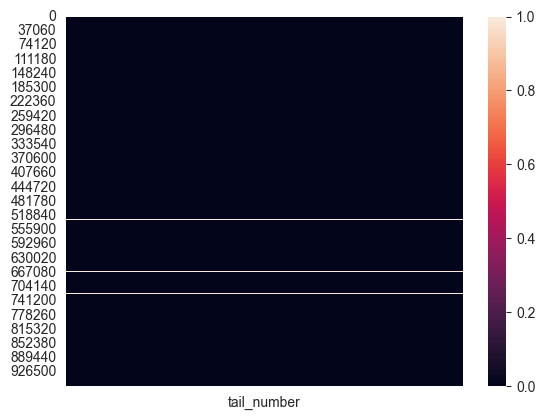

In [15]:
# checking the null entries

# counting the number and percentage of null entries
print(f"There are {all_airports_df.isna().any(axis=1).sum()} rows with null entries.")
print(f"The percentage of null entries is {(all_airports_df.isna().any(axis=1).sum()/len(all_airports_df)*100):.2f}%")

# checking for any patterns in the null entries
sns.heatmap(all_airports_df[['tail_number']].isnull())

Since all our null entries are spread all across the dataset, it cannot be correlated to the origin airport, since it is spread out. If it does not relate to the carrier in any way, then there is no easily identifiable correlation between the two.

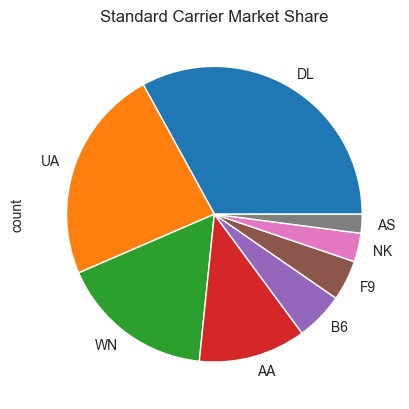

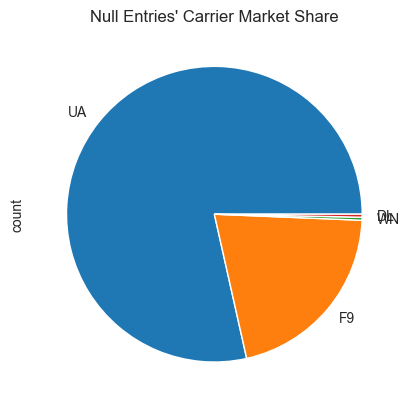

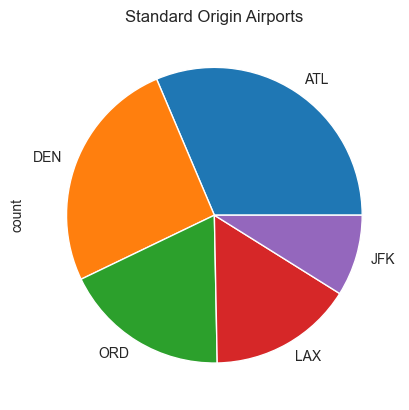

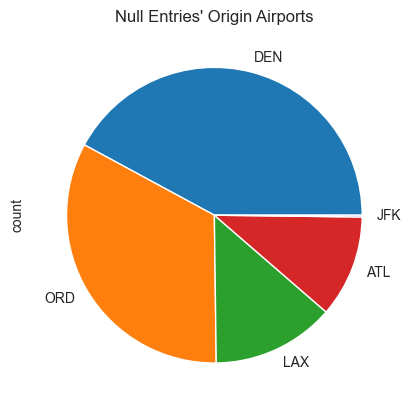

In [16]:
# checking if the carriers of the null entries differ from the carriers of the normal dataset

# standard carrier pie
all_airports_df['carrier_code'].value_counts().plot(kind='pie')
plt.title("Standard Carrier Market Share")
plt.show()

# null entries carrier pie
null_df = all_airports_df[all_airports_df.isna().any(axis=1)]
null_df['carrier_code'].value_counts().plot(kind='pie')
plt.title("Null Entries' Carrier Market Share")
plt.show()

# standard origin airport pie
all_airports_df['origin'].value_counts().plot(kind='pie')
plt.title("Standard Origin Airports")
plt.show()

# null entries origin airport pie
null_df = all_airports_df[all_airports_df.isna().any(axis=1)]
null_df['origin'].value_counts().plot(kind='pie')
plt.title("Null Entries' Origin Airports")
plt.show()

We can clearly see that United and Frontier flights make up almost all the null flights., with small differences in which airport has the most null entries. This makes me associate the missing data to some mistake in the data handling related to United and Frontier specifically. In any case, the nulls can be classified under MNAR. Since they make up only 0.38% of the dataset, and since the tail number of a flight is a unique number that cannot be inferred from elsewhere, I've chosen to drop the rows with the missing entries.

In [17]:
# dropping the rows with null entries
all_airports_df.dropna(inplace=True)

## C- Feature Engineering

Now that we are done with renaming our columns, it is time for our feature engineering. We will:
* Add any columns that I believe to be useful in understanding and modeling the data
* Drop any columns that are not useful or might undermine our modeling
* Handle outliers
* Encode and scale our data as needed

I will be adding the following columns:

1. is_delayed (boolean)<br>
This column will tell whether a flight had a delayed departure or not, which is measured as a delay of 15 minutes or more past the scheduled departure time.

2. is_very_delayed (boolean)<br>
This column will tell whether a flight had a very delayed departure or not, which is measured as a delay of 60 minutes or more past the scheduled departure time.
3. is_majorly_delayed (boolean)<br>
This column will tell whether a flight had a very delayed departure or not, which is measured as a delay of 180 minutes or more past the scheduled departure time.
4. month(int64)<br>
This column will contain the month the flight departed on. The year will be omitted since the entire dataset is in 2024.
5. day (int64)<br>
This column will contain the day the flight departed on
6. day_of_week (int64)<br>
This column will contain what day of the week the flight departed on. This column will be encoded in 0 to 6, from Monday to Sunday.
7. schedule_hour (int64)<br>
This column will contain the hour the flight was scheduled to depart on
8. scheduled_minute (int64)<br>
This column will contain the minute the flight was scheduled to depart on
9. actual_hour (int64)<br>
This column will contain the hour the flight actually departed on
10. actual_minute (int64)<br>
This column will contain the minute the flight actually departed on
11. is_weekend (boolean)<br>
This column will tell whether the day the flight took off on was a weekend or not
12. is_holiday (boolean)<br>
This column will tell whether the day the flight took off on was a weekend or not
13. other_delay (int64)<br>
This column will calculate the number of minutes a flight was delayed that were not accounted for in the other reason-specific columns

The reason the date and time columns were split up was so the model can make sense of the data in a more useful manner, as the model may not be able to understand the complexity of a datatime object, so breaking it down will make it more likely for the model to draw useful conclusions from the data. The is_delayed column was added since it will help us filter the data as well as be our target for our model, and other_delay was added so that every minute of delay is accounted for.

In [18]:
# adding non-time related columns
# delay booleans
delay_in_minutes = ((all_airports_df['actual_departure_time'] - all_airports_df['scheduled_departure_time']).dt.total_seconds() / 60)
all_airports_df['is_delayed'] =  (delay_in_minutes >= 15)
all_airports_df['is_very_delayed'] = delay_in_minutes >= 60
all_airports_df['is_majorly_delayed'] = delay_in_minutes >= 180


# delay explanations
all_airports_df['other_delay'] = (all_airports_df['departure_delay'] - (
    all_airports_df['carrier_delay'] +
    all_airports_df['weather_delay'] +
    all_airports_df['nas_delay'] +
    all_airports_df['late_aircraft_delay']
)).clip(lower=0)

In [19]:
# converting the date and time into integer columns
columns_to_drop = []

#date
all_airports_df['month'] = all_airports_df['date'].dt.month
all_airports_df['day'] = all_airports_df['date'].dt.day

#scheduled departure time
all_airports_df['scheduled_hour'] = all_airports_df['scheduled_departure_time'].dt.hour
all_airports_df['scheduled_minute'] = all_airports_df['scheduled_departure_time'].dt.minute
columns_to_drop.append('scheduled_departure_time')

#actual departure time
all_airports_df['actual_hour'] = all_airports_df['actual_departure_time'].dt.hour
all_airports_df['actual_minute'] = all_airports_df['actual_departure_time'].dt.minute
columns_to_drop.append('actual_departure_time')

# day of the week and weekend
all_airports_df['day_of_week'] = all_airports_df['date'].dt.weekday
all_airports_df['is_weekend'] = all_airports_df['day_of_week'].isin([5, 6])

# holidays
holiday_dates = [
    datetime(2024, 1, 1),   # New Year's Day
    datetime(2024, 1, 15),  # Martin Luther King Jr. Day
    datetime(2024, 2, 19),  # Presidents' Day
    datetime(2024, 5, 27),  # Memorial Day
    datetime(2024, 6, 19),  # Juneteenth
    datetime(2024, 7, 4),   # Independence Day
    datetime(2024, 9, 2),   # Labor Day
    datetime(2024, 10, 14), # Columbus Day
    datetime(2024, 11, 11), # Veterans Day
    datetime(2024, 11, 28), # Thanksgiving Day
    datetime(2024, 12, 25), # Christmas Day
]
all_airports_df['is_holiday'] = all_airports_df['date'].isin(holiday_dates)

Now that we have added all the columns that we will need, we will begin to remove any columns that are either redundant or that serve no purpose to finding out whether a flight is delayed and thus might throw off the modeling. We will keep the date column only to use as a key for any future databases we want to link to this one, but we will not use it for any analysis or modeling.

In [20]:
# picking the columns to be dropped
columns_to_drop.append('flight_number')
columns_to_drop.append('tail_number')

# dropping the columns
all_airports_df.drop(columns_to_drop, axis=1, inplace=True)

Now, we will begin encoding all our categorical features. Since we will be using the random forest model for this project, it is okay to encode using regular label encoding since it will not be considered in order.

In [21]:
# encoding categorial data
#strings
# carrier
encoder = LabelEncoder()
encoder.fit(all_airports_df['carrier_code'])
carrier_code_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
all_airports_df['carrier_code'] = encoder.transform(all_airports_df['carrier_code'])

# destination
encoder = LabelEncoder()
encoder.fit(all_airports_df['destination'])
destination_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
all_airports_df['destination'] = encoder.transform(all_airports_df['destination'])

# origin
encoder = LabelEncoder()
encoder.fit(all_airports_df['origin'])
origin_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
all_airports_df['origin'] = encoder.transform(all_airports_df['origin'])

# booleans
# is delayed
encoder = LabelEncoder()
all_airports_df['is_delayed'] = encoder.fit_transform(all_airports_df['is_delayed'])

#is_very_delayed
encoder = LabelEncoder()
all_airports_df['is_very_delayed'] = encoder.fit_transform(all_airports_df['is_very_delayed'])

#is_majorly_delayed
encoder = LabelEncoder()
all_airports_df['is_majorly_delayed'] = encoder.fit_transform(all_airports_df['is_majorly_delayed'])

# is weekend
encoder = LabelEncoder()
all_airports_df['is_weekend'] = encoder.fit_transform(all_airports_df['is_weekend'])

#is holiday
encoder = LabelEncoder()
all_airports_df['is_holiday'] = encoder.fit_transform(all_airports_df['is_holiday'])


# printing our encoding maps
weekday_mapping = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}
print(f"The carriers got encoded as follows: {carrier_code_mapping}")
print(f"The origin airports got encoded as follows: {origin_mapping}")

The carriers got encoded as follows: {'AA': 0, 'AS': 1, 'B6': 2, 'DL': 3, 'F9': 4, 'NK': 5, 'UA': 6, 'WN': 7}
The origin airports got encoded as follows: {'ATL': 0, 'DEN': 1, 'JFK': 2, 'LAX': 3, 'ORD': 4}


We have encoded all our categorical features, and saved their mappings in dictionaries for future reference. Please note that we didn't save the mappings of boolean features since in those columns, we use the standard 1 for true, 0 in for false. As for scaling: since we will be using the random forest model, I did not find it necessary to scale our integer features, particularly because they are all measuring the same unit: minutes of time, thus you can still compare them to one another.
<br>

We are now at a very critical point. We have cleaned up this dataset, encoded our categorical features, and added features that I believe will be useful. However, as we now begin with doing correlations and scaling in preparation for our modeling, I think it is best to now save this dataframe into a new CSV file, which from this point forward will be considered our 'raw data' for our model, rather than the airline-specific CSV files from earlier. Once we save the file, we will begin our correlations.

In [22]:
# saving our dataframe into a new raw data file
all_airports_df.to_csv('/flight_delay_model_data/data_preprocessing/raw_flight_data/complete_raw_airport_data.csv', index=False, sep=",")

Now that our data has been saved, we can begin adding additional columns to it without destroying the original raw data. This brings us to the most critical aspect of this entire project: handling the outliers in our dataset. As airlines strive to have good on-time performance, delays are almost fundamentally always going to be outliers and this presents a problem when trying to understand our data, whether it terms of modeling, correlation computing or any form of analysis we'd like to perform on this data. There are very strong outliers in this data, particularly when it comes to the reason-specific delay minutes. Let us delve into them:
<br>

First, we need to define what an outlier is. To do this, let us look at each delay column's data individually and decide based a combination of graphs, percentiles and the standard IQR method.

Analysis of departure_delay:
The percentage of entries equal to zero is 59.52%
The number of outliers based on the IQR method is 143280, which accounts for 14.93% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 11.0
85th percentile: 27.0
90th percentile: 45.0
95th percentile: 82.0
97th percentile: 115.0
99th percentile: 201.0
There are 9553 entries after this percentile, which is 1.00% of the data
The highest value in the outliers is 2640


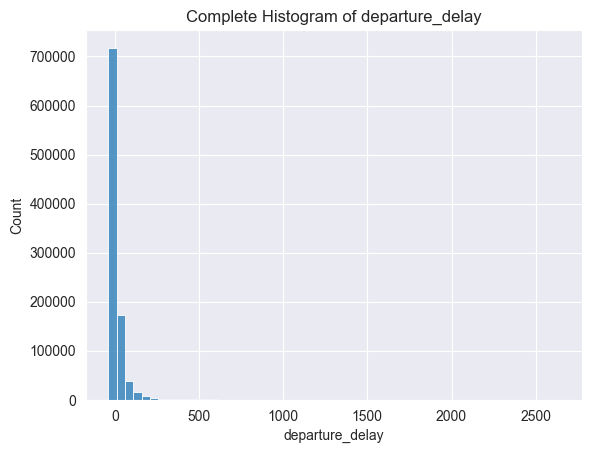

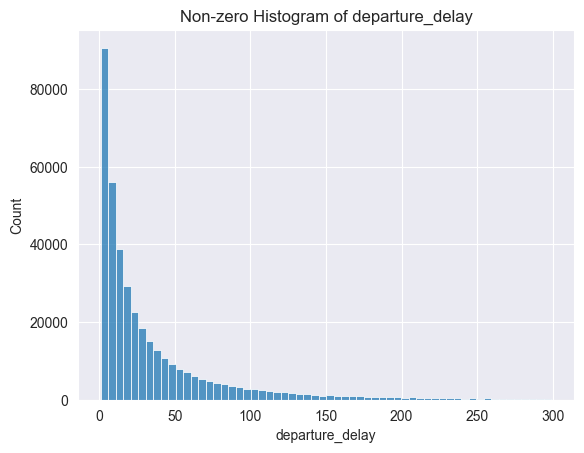

Analysis of carrier_delay:
The percentage of entries equal to zero is 86.92%
The number of outliers based on the IQR method is 125516, which accounts for 13.08% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
85th percentile: 0.0
90th percentile: 9.0
95th percentile: 28.0
97th percentile: 46.0
99th percentile: 109.0
There are 9467 entries after this percentile, which is 0.99% of the data
The highest value in the outliers is 2353


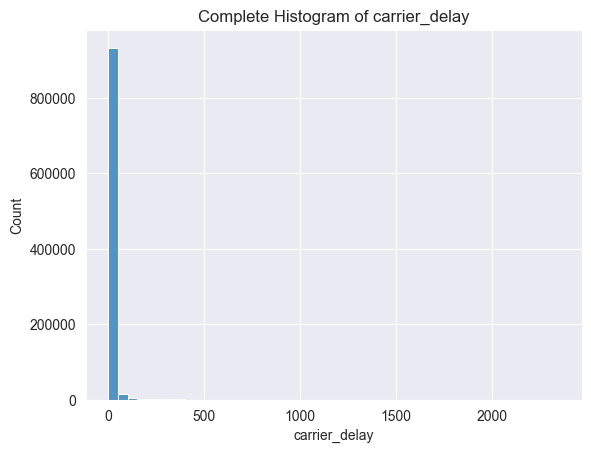

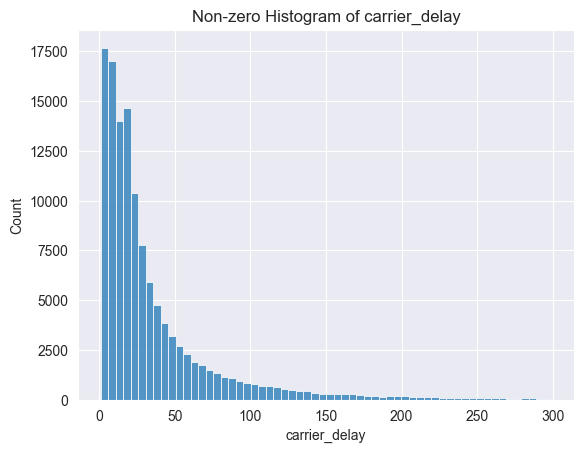

Analysis of weather_delay:
The percentage of entries equal to zero is 99.23%
The number of outliers based on the IQR method is 7425, which accounts for 0.77% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
85th percentile: 0.0
90th percentile: 0.0
95th percentile: 0.0
97th percentile: 0.0
99th percentile: 0.0
There are 7425 entries after this percentile, which is 0.77% of the data
The highest value in the outliers is 1137


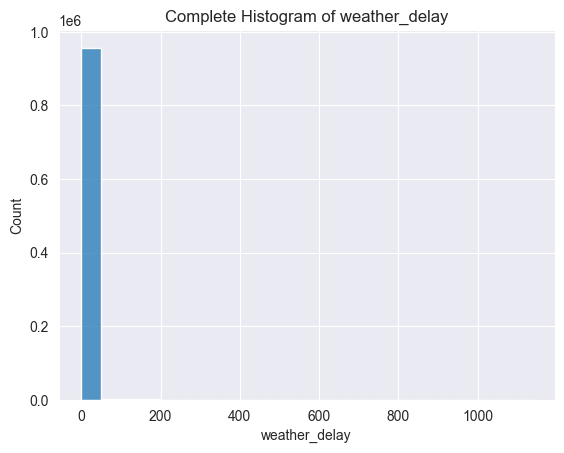

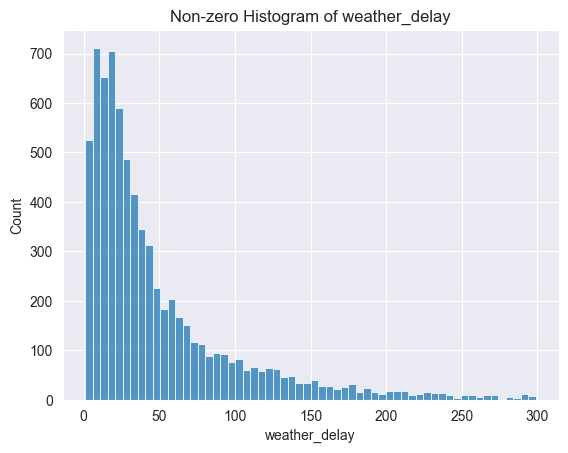

Analysis of nas_delay:
The percentage of entries equal to zero is 88.65%
The number of outliers based on the IQR method is 108938, which accounts for 11.35% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
85th percentile: 0.0
90th percentile: 3.0
95th percentile: 19.0
97th percentile: 29.0
99th percentile: 61.0
There are 9453 entries after this percentile, which is 0.98% of the data
The highest value in the outliers is 968


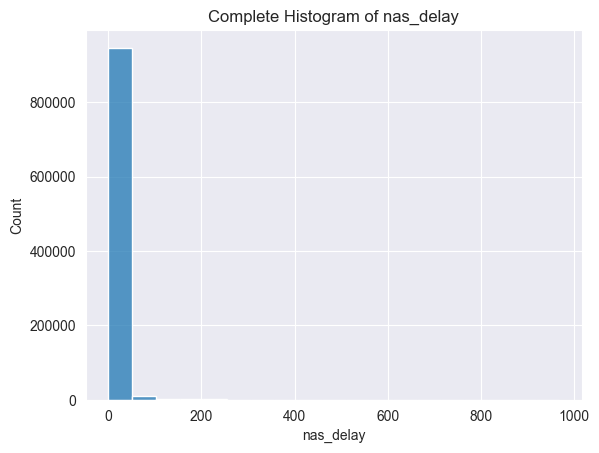

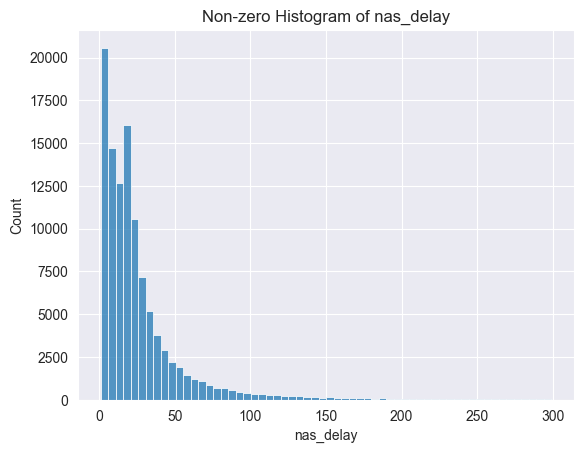

Analysis of security_delay:
The percentage of entries equal to zero is 99.92%
The number of outliers based on the IQR method is 734, which accounts for 0.08% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
85th percentile: 0.0
90th percentile: 0.0
95th percentile: 0.0
97th percentile: 0.0
99th percentile: 0.0
There are 734 entries after this percentile, which is 0.08% of the data
The highest value in the outliers is 1005


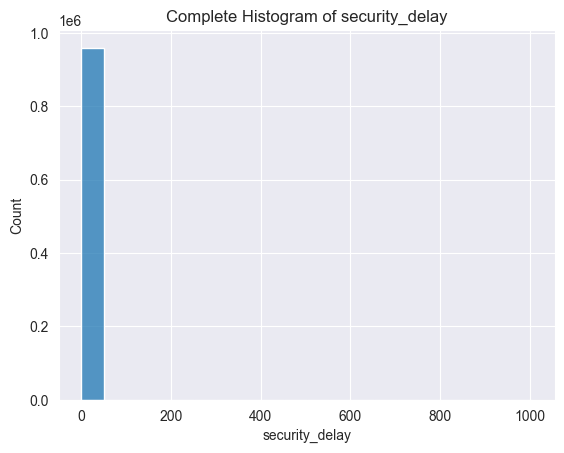

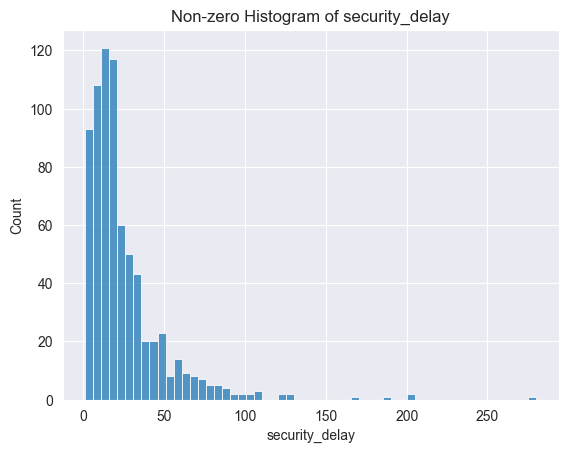

Analysis of late_aircraft_delay:
The percentage of entries equal to zero is 89.63%
The number of outliers based on the IQR method is 99563, which accounts for 10.37% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
85th percentile: 0.0
90th percentile: 3.0
95th percentile: 33.0
97th percentile: 57.0
99th percentile: 121.0
There are 9513 entries after this percentile, which is 0.99% of the data
The highest value in the outliers is 2506


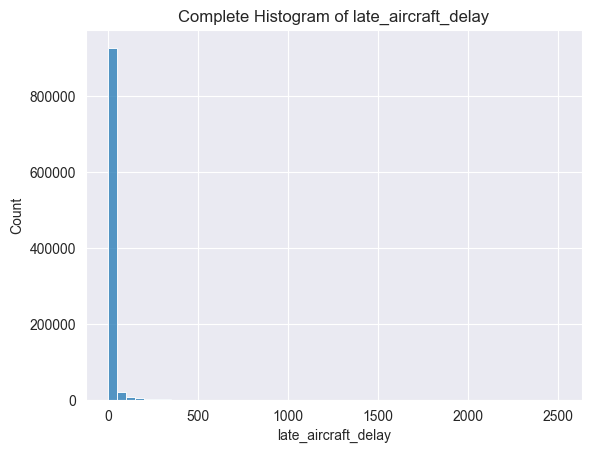

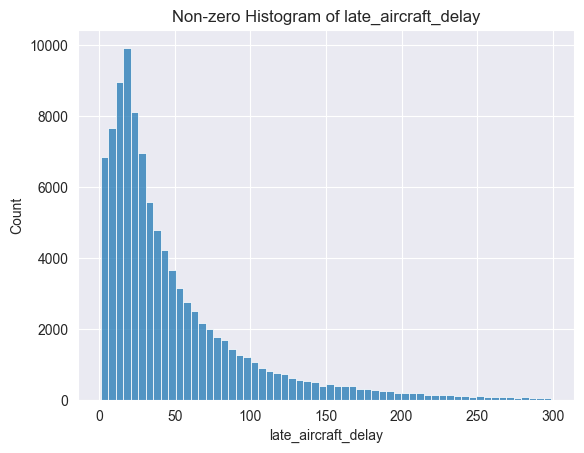

Analysis of other_delay:
The percentage of entries equal to zero is 68.21%
The number of outliers based on the IQR method is 160673, which accounts for 16.74% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 3.0
85th percentile: 9.0
90th percentile: 12.0
95th percentile: 18.0
97th percentile: 21.0
99th percentile: 29.0
There are 8561 entries after this percentile, which is 0.89% of the data
The highest value in the outliers is 1299


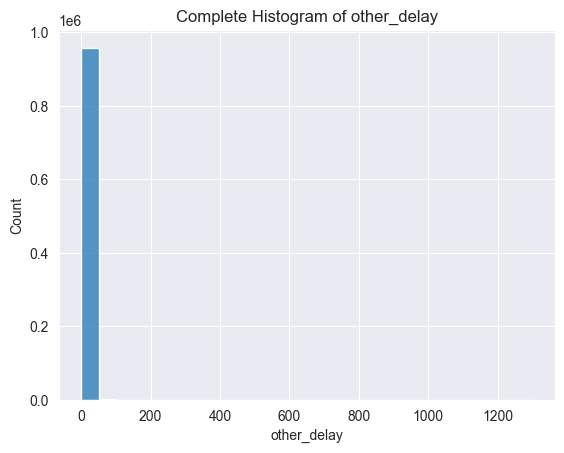

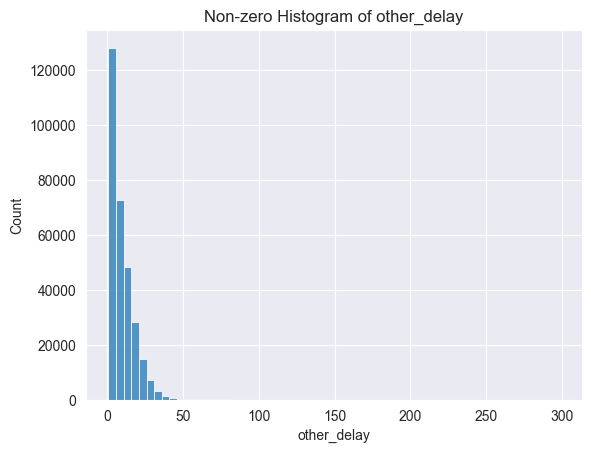

In [23]:
# analyzing our features with outliers
delay_columns = ['departure_delay','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay','other_delay']
for column in delay_columns:
    print(f"Analysis of {column}:")
    ratio_of_zeros = len(all_airports_df[all_airports_df[column].clip(lower=0) == 0])/len(all_airports_df) * 100
    q3 = all_airports_df[column].clip(lower=0).quantile(0.75)
    q2 = all_airports_df[column].clip(lower=0).quantile(0.50)
    q1 = all_airports_df[column].clip(lower=0).quantile(0.25)
    p99 = all_airports_df[column].clip(lower=0).quantile(0.99)
    iqr = q3 - q1
    upper_limit = q3 + 1.5*iqr
    iqr_outlier_count = len(all_airports_df[all_airports_df[column] > upper_limit])
    iqr_outlier_count_ratio = iqr_outlier_count / len(all_airports_df) * 100
    p99_count = len(all_airports_df[all_airports_df[column] > p99])
    p99_count_ratio = p99_count / len(all_airports_df) * 100
    print(f"The percentage of entries equal to zero is {ratio_of_zeros:.2f}%")
    print(f"The number of outliers based on the IQR method is {iqr_outlier_count}, which accounts for {iqr_outlier_count_ratio:.2f}% of the data")
    print("The percentiles were as follows:\n"
          f"25th percentile: {q1}\n"
          f"50th percentile: {q2}\n"
          f"75th percentile: {q3}\n"
          f"85th percentile: {all_airports_df[column].clip(lower=0).quantile(0.85)}\n"
          f"90th percentile: {all_airports_df[column].clip(lower=0).quantile(0.90)}\n"
          f"95th percentile: {all_airports_df[column].clip(lower=0).quantile(0.95)}\n"
          f"97th percentile: {all_airports_df[column].clip(lower=0).quantile(0.97)}\n"
          f"99th percentile: {p99}\n"
          f"There are {p99_count} entries after this percentile, which is {p99_count_ratio:.2f}% of the data\n"
          f"The highest value in the outliers is {all_airports_df[column].max()}"
          )
    sns.histplot(data=all_airports_df[column],binwidth=50)
    plt.title(f"Complete Histogram of {column}")
    plt.show()
    sns.histplot(data=all_airports_df[(all_airports_df[column].clip(lower=0) != 0) & (all_airports_df[column].clip(lower=0) < 300)][column],binwidth=5)
    # each bin is five minutes
    plt.title(f"Non-zero Histogram of {column}")
    plt.show()


### 1- Insights:
There is a lot of insight that we can draw from this data if we read between the lines. Firstly and most importantly, the column of delay minutes is relatively less skewed to the right than the delay reasons themselves, as the values of the delay in departure for each percentile is larger than the value of any one reason at the same percentile. This would mean, that when a plane is delayed, it is often a mix of smaller delays across multiple fields rather than one singular reason that takes a long time, which is proved further by how the secondary graphs.<br>

Additionally, it can be noted that while the ratio of the explicitly mentioned reasons for delay is usually around 10-14%, weather and security delays are very notable exceptions, as they rarely every occur, with a non-zero ratio of higher than 99%, even more so with security delays which only have 100 delays out of a dataset of a million entries. Thus, we can conclude that they are very strong oddities. However, whether they should remain in the dataset or not would have to depend on their minimum delay time, which we can analyze now, and their correlation to delays, which we can analyze in the correlation calculation, as in correlation, we will be able to compare the difference in correlation between minor, normal, and major delays, as per the boolean columns we have added to our set.<br>

Finally, I should mention that from the secondary graphs, which show the progression of the actual delay times in 15-minute intervals, we can see that weather delays and especially aircraft delays are both heavy-hitters, meaning that regardless of their frequency, their presence has a high chance of creating a delay that is alone more than 15 minutes and making our flight delayed. That should mean that we need to give them outsized importance when it comes to modeling our delay mode. <br>

### 2- Outlier Handling
Based on everything, I think the outliers in the departure delay and other delay should be handled differently than the reason-specific delays, due to the rarity of non-zeros in the reasons columns compared to the total delay minutes and the other delays column, and we will get to those later. For the specific-reason delay columns, I would say that the best way to handle the outliers in the delay reasons columns, which are the most severe, depends on whether we are going to use it for modeling purposes or correlation and analysis purposes. For modeling, it would depend entirely on the model we're speaking of, since this model will use two. <br>

* #### Delay Possibility (Random Forest):
    For this model, it would make more sense to turn the delay reasons into booleans since in the grand scheme of all flights, they are almost all outliers,especially the amount of delays necessary to be greater than fifteen minutes, which is our metric for a flight to be 'delayed'. Thus, we will train the model on the booleans and thus the value of the outlier is irrelevant.<br>

* #### Delay Amount (Linear Regression):
    Since delay amounts only occur in planes which are in fact delayed, the delay model will be trained on a subset of the dataset, a subset where is_delayed is true. In this case, the zeros will be increasingly rare, thus making the data overall less skewed to the right. Regardless, we would still need to handle the outliers, and for that, we have to first define what an 'outlier' would be. For the linear regression model, I will initially define outliers through the business-adjacent understanding that anything beyond 180 minutes (3 hours) is very abnormal, and we will resolve the other outliers by winsorizing to 180. Our non-zero entries will still probably delayed, but that is the entire goal. We can see through the secondary graph that the variability in non-zero entries will not be  majorly affected by winsorizing to 180, but what this does is that it allows there to be no outliers within the outliers, so to speak. I will also perform this on the overall departure delay and other delay columns, since it would remove the same concept of 'outliers within outliers'.

For correlations, it would make sense to measure them using the booleans, since they are outliers and would mess up almost every other correlation measurement that doesn't inherently work on a dichotomous basis.

To summarize, we will create new two sets for columns for the delay-reason columns:
* A set of boolean columns that measure whether the delay is zero or not.
* A set of winsorized numerical columns that will measure the delay in minutes without the extreme outliers.

In [24]:
# handling measurement error outliers (only one was found in security delay)
try:
    all_airports_df= all_airports_df.drop(818511)
except:
    pass

# creating a new list for easier looping
delay_reason_columns = ['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay','other_delay']

# creating boolean columns
for column in delay_reason_columns:
    all_airports_df[f'has_{column}'] = all_airports_df[column].clip(lower=0).apply(lambda x: 0 if x == 0 else 1)


# creating numerical outliers-free columns
for column in delay_columns:
    all_airports_df[f"winsorized_{column}"] = all_airports_df[column].clip(upper=180)

## D- Correlation Analysis Engineering

Our data is now ready to begin correlation analysis. In this section we will:
* Choose and explain the correlation coefficients we will use
* Prepare and group the data in preparation for computation
* Compute and displaying the correlation analysis
* Analyze and comment on the results

Now, we can begin with our correlation analysis. Firstly, we will begin with describing what correlation coefficients we'll be using, and then the adjustments we'll be doing to the data in order to use the decided coefficients. We will use create three groups for our features and find the correlation between each group: booleans, categorical, and numerical. Each feature will be grouped into one of these based either on the raw data, or how we chose to represent said raw data if the raw data was not in an easily computable form. Here are the changes I will make to each one:

* Log Transformation: Will be applied to our numerical columns to make them normal or close to normal, since they are almost all skewed, as well as make our outliers less severe. This will be used in testing the correlation for non-reason specific delay columns.
* Circular Transformation: In order for our correlations to understand time in a more realistic understanding, we will make the minutes and hours form a cosine loop, that way it can be understood better in correlations and modeling purposes.


<br>
Knowing this, here are the correlation coefficients I'll use and why:

<h3> 1. Spearman's</h3>
<h4 style="margin-top:-10px;"><i>Numerical to numerical</i></h4>

I chose to use spearman's for our numerical correlations rather than pearson's since it is the safer option considering we have a lot of outliers in our data.

<h3> 2. Point-Biserial</h3>
<h4 style="margin-top:-10px;"><i>Numerical to boolean</i></h4>

It makes the most sense, since our booleans are obviously made of only two choices, 1 or 0.

<h3> 3. Welch's ANOVA / Kruskal-Wallis </h3>
<h4 style="margin-top:-10px;"><i>Numerical to categorical</i></h4>

Choosing correlation coefficients for categorical data is a particular challenge, since we need to pick a coefficient that does not measure the increase in the number of some category as a meaningful, quantitative change, but merely measure the numbers as distinctive. ANOVA does this and so does Kruskal, but the reason will use both depends on the skewness of the data we're checking the correlation of.

<h3> 4. Cramer's V </h3>
<h4 style="margin-top:-10px;"><i>Categorical to categorical, categorical to boolean, boolean to boolean</i></h4>

Standard correlation coefficient for all categorical data, which booleans technically are. The distinction was only made for the difference in using numerical coefficients.
<br>
<br>

Now that we have decided the correlation coefficients we will use, we will first group the columns in lists, then apply the changes above, then finally creating the correlation models.

In [25]:
# making our time columns circular in nature

# making lists to for loopable column creation
raw_hour_columns = ['scheduled_hour','actual_hour']
raw_minute_columns = ['scheduled_minute','actual_minute']

# hour columns
for column in raw_hour_columns:
    all_airports_df[f"sin_circular_{column}"],all_airports_df[f"cos_circular_{column}"] = make_time_cyclical(all_airports_df[column],'hour')

# minute columns
for column in raw_minute_columns:
    all_airports_df[f"sin_circular_{column}"],all_airports_df[f"cos_circular_{column}"] = make_time_cyclical(all_airports_df[column],'minute')

# month column
all_airports_df['sin_circular_month'],all_airports_df['cos_circular_month'] = make_time_cyclical(all_airports_df['month'],'month')

# day column
month_length_mapping = {
    2: 'day29',
    4: 'day30', 6: 'day30', 9: 'day30', 11: 'day30',
    1: 'day31', 3: 'day31', 5: 'day31', 7: 'day31', 8: 'day31', 10: 'day31', 12: 'day31'
}

all_airports_df['temp_month_type'] = all_airports_df['month'].map(month_length_mapping)

all_airports_df['sin_circular_day']  = (all_airports_df.apply
    (
    lambda current_row: make_time_cyclical(current_row['day'],current_row['temp_month_type'],func='sin'),axis=1
    )
)

all_airports_df['cos_circular_day']  = (all_airports_df.apply
    (
    lambda current_row: make_time_cyclical(current_row['day'],current_row['temp_month_type'],func='cos'),axis=1
    )
)
all_airports_df = all_airports_df.drop(columns='temp_month_type')

# day of week column
all_airports_df['sin_circular_day_of_week'], all_airports_df['cos_circular_day_of_week'] = make_time_cyclical(all_airports_df['day_of_week'],'weekday')

In [26]:
# applying our logarithmic transformations

# measuring skewness pre-transformation
pre_log_columns = ['winsorized_departure_delay',
                   'winsorized_carrier_delay',
                   'winsorized_weather_delay',
                   'winsorized_nas_delay',
                   'winsorized_security_delay',
                   'winsorized_late_aircraft_delay',
                   'winsorized_other_delay']

print("Pre-transformation skewness and kurtosis")
print('Skewness:')
for column in pre_log_columns:
    print(f"{column}'s skew: {all_airports_df[column].skew():.2f}")
print('\nKurtosis:')
for column in pre_log_columns:
    print(f"{column}'s kurtosis: {kurtosis(all_airports_df[column]):.2f}")

# applying logarithmic transformations
post_log_columns = []
for column in pre_log_columns:
    all_airports_df[f"log_{column}"] = np.log(all_airports_df[column].clip(lower=1))
    new_column = f"log_{column}"
    post_log_columns.append(new_column)

# measuring new skewness
print("\n ----- \n")
print("Post-transformation skewness")
print("Skewness:")
for column in post_logw_columns:
    print(f"{column}: {all_airports_df[column].skew():.2f}")
print('\nKurtosis:')
for column in post_log_columns:
    print(f"{column}'s kurtosis: {kurtosis(all_airports_df[column]):.2f}")

Pre-transformation skewness and kurtosis
Skewness:
winsorized_departure_delay's skew: 3.14
winsorized_carrier_delay's skew: 6.20
winsorized_weather_delay's skew: 21.59
winsorized_nas_delay's skew: 7.67
winsorized_security_delay's skew: 86.54
winsorized_late_aircraft_delay's skew: 5.67
winsorized_other_delay's skew: 6.71

Kurtosis:
winsorized_departure_delay's kurtosis: 10.69
winsorized_carrier_delay's kurtosis: 44.45
winsorized_weather_delay's kurtosis: 528.19
winsorized_nas_delay's kurtosis: 76.72
winsorized_security_delay's kurtosis: 10496.11
winsorized_late_aircraft_delay's kurtosis: 36.27
winsorized_other_delay's kurtosis: 112.32

 ----- 

Post-transformation skewness
Skewness:
log_winsorized_departure_delay: 1.08
log_winsorized_carrier_delay: 2.75
log_winsorized_weather_delay: 12.64
log_winsorized_nas_delay: 3.04
log_winsorized_security_delay: 40.85
log_winsorized_late_aircraft_delay: 3.00
log_winsorized_other_delay: 1.38

Kurtosis:
log_winsorized_departure_delay's kurtosis: -0.31

Now we are done with all the chances and prepared the data, it is finally time to calculate the correlations. We will firstly split all our columns into one of the three groupings. To do this, we will first write out the columns of this dataset. For any column that is expressed in multiple ways, they will be written together, with the ones that we will use for correlation analysis in italics.

#### Our columns:
* Carrier code
* Origin
* Destination
* Month / _Circular month_
* Day / _Circular day_
* _Scheduled hour_ / _Sin circular scheduled hour_ / _Cosine circular scheduled hour_
* _Scheduled minute_ / _Sin circular scheduled minute_ / _Cosine circular scheduled minute_
* _Actual hour_ / _Sin circular actual hour_ / _Cosine circular actual hour_
* _Actual minute_ / _Sin circular actual minute_ / _Cosine circular actual minute_
* _Day of week_ / _Sin circular day of week_ / _Cosine circular day of week_
* Is weekend
* Is holiday
* Is delayed
* Is very delayed
* Is majorly delayed
* Departure delay / _winsorized departure delay_ / _log winsorized departure delay_
* Carrier delay / _winsorized carrier delay_ / log winsorized carrier delay / _has carrier delay_
* Weather delay / _winsorized weather delay_ / log winsorized weather delay / _has weather delay_
* Nas delay / _winsorized nas delay_ / log winsorized nas delay / _has nas delay_
* Security delay / _winsorized security delay_ / log winsorized security delay / _has security delay_
* Late aircraft delay / _winsorized late aircraft delay_ / log winsorized late aircraft delay / _has late aircraft delay_
* Other delay / _winsorized other delay_ / _log winsorized other delay_

Now we will write below where each column will be represented, with any subsets included, and any explanations added if needed. <br>
An important note is that the delay-reason columns will be represented multiple times using different methods, and we will measure their correlation to the dataset based on the result of all the correlation results. This is since, although they are numerical in nature, have weird properties.
<br>

### 1- Numerical Features
#### a- Fully numerical
* Sin circular month
* Sin circular day
* Sin circular scheduled hour
* Sin circular scheduled minute
* Sin circular actual hour
* Sin circular actual minute
* Cosine circular month
* Cosine circular day
* Cosine circular scheduled hour
* Cosine circular scheduled minute
* Cosine circular actual hour
* Cosine circular actual minute

#### b- Conditionally numerical
The following features are conditionally numerical as in that they will not always be included in correlation analysis with "numerical", and will be added/dropped based on the method being used.
#### (Set I)
These are the closest ones to being normal, with the least amount of non-zeros
* Winsorized departure delay
* Winsorized other delay

#### (Set II)
These have a smaller amount of non-zeros, but in the 10% range
* Winsorized carrier delay
* Winsorized nas delay
* Winsorized late aircraft delay
* Winsorized other delay

#### (Set III)
These are the columns with barely any non-zeros, nearing on 1%
* Winsorized weather delay
* Winsorized security delay
<br>

### 2- Categorical Features
Note that these are all encoded, and so we should use correlation methods which are unranked
#### a- Fully Categorical
* Carrier code
* Origin
* Destination
#### a- Conditionally Categorical
Although these are measured in the numerical columns, this is to double-check the correlations, since the splitting of time columns into sin and cosine might mess with the correlations
* Scheduled Hour
* Actual Hour
* Scheduled Minute
* Actual Minute
* Month
* Day
* Day of Week
<br>

### 3- Boolean Features
#### a- Fully boolean
* Is weekend
* Is holiday
* Is delayed
* Is very delayed
* Is majorly delayed
#### b- Conditionally boolean
These are conditionally boolean in the sense that they will be represented in the correlation with numerical features twice.
* Has carrier delay
* Has weather delay
* Has nas delay
* Has security delay
* Has late aircraft delay
<br>

We will now create these lists, and begin the correlation analysis on them.

In [27]:
# creating our groupings

#numerical
fully_numerical = [
                    'sin_circular_month',
                    'cos_circular_month',
                    "sin_circular_day",
                    "cos_circular_day",
                    "sin_circular_scheduled_hour",
                    "cos_circular_scheduled_hour",
                    "sin_circular_scheduled_minute",
                    "cos_circular_scheduled_minute",
                    "sin_circular_actual_hour",
                    "cos_circular_actual_hour",
                    "sin_circular_actual_minute",
                    "cos_circular_actual_minute",
                   ]

conditionally_numerical_1 = [
                    "winsorized_departure_delay",
                    "winsorized_other_delay",
                    ]

conditionally_numerical_1_logged = [
                    "log_winsorized_departure_delay",
                    "log_winsorized_other_delay",
                    ]


conditionally_numerical_2 = [
                    "winsorized_carrier_delay",
                    "winsorized_nas_delay",
                    "winsorized_late_aircraft_delay"
                    ]


conditionally_numerical_3 = [
                    "winsorized_weather_delay",
                    "winsorized_security_delay",
                    ]


# type 1: in spearman's
numerical_columns_type_1 = fully_numerical + conditionally_numerical_1 + conditionally_numerical_2 + conditionally_numerical_3

# type 2: in point-biserial
numerical_columns_type_2 = fully_numerical + conditionally_numerical_1_logged

# type 3: in ANOVA (a) / Kruskal-Wallis (b)
numerical_columns_type_3a = fully_numerical + conditionally_numerical_1_logged
numerical_columns_type_3b =  conditionally_numerical_1_logged + conditionally_numerical_2 + conditionally_numerical_3


# categorical
# categorical to numerical
fully_categorical_columns = [
                    "carrier_code",
                    "origin",
                    "destination",
                    ]

# categorical to categorical/boolean
conditional_categorical_columns = [
                    "scheduled_hour",
                    "actual_hour",
                    "scheduled_minute",
                    "actual_minute",
                    "month",
                    "day",
                    "day_of_week"
                    ]
categorical_columns_type_1 = fully_categorical_columns
categorical_columns_type_2 = fully_categorical_columns + conditional_categorical_columns

# boolean
fully_boolean =     [
                    "is_weekend",
                    "is_holiday",
                    "is_delayed",
                    "is_very_delayed",
                    "is_majorly_delayed"
                    ]

conditionally_boolean = [
                    "has_carrier_delay",
                    "has_weather_delay",
                    "has_nas_delay",
                    "has_security_delay",
                    "has_late_aircraft_delay",
                    "has_other_delay"
                     ]


boolean_columns = fully_boolean + conditionally_boolean

If you took notice to the code, you will notice that I have created three different lists for the numerical columns, one for each correlation method being tested. This fundamentally stems from the fact that the delay columns, especially the reason-specific columns are very skewed and inherently measure outliers, which is very hard to measure in correlation factors, most of which assume normality of data or are sensitive to outliers. Due to this, I have made a list of three lists for each method that are uniquely tailored to the correlation coefficient being measured. Here are the justifications for each:

#### 1- Spearman's: _All numerical columns_
Since spearman's is not as sensitive to outliers, all the winsorized versions of the columns can be used. The sensitivity to outliers in spearman's comes from the difference it would make in the ranking of numbers, which is significantly reduced by being capped at 180, since there is a healthy amount of delays between the median and 180.

#### 2- Point-biserial: _Fully numerical + Set 1_
Since the point-biserial is a specialized version of Pearson's coefficient, it needs to follow the same assumptions, namely that our data is close to normal. This is when the skew and kurtosis (Fisher's method) are equal to zero, and the fully numerical columns and set 1 are the only ones within the +/- 1 range of those, particularly in skew. Since the other columns don't have these properties, we won't calculate them in our point-biserial since the result will be inaccurate anyway.

#### 3- a. Welch's ANOVA: _Fully numerical + Logged set 1_
<h4 style="margin-top: -5px;">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;b. Kruskal-Wallis: <i>Logged set 1 + Set 2 + Set 3</i></h4>
This was the one that required the most complex decision. ANOVA assumes the data to be normal, and thusly cannot accept most delay columns, even when winsorized, which is why I decided that for every categorical feature, its correlation with the numerical columns will be measured with ANOVA for the normal ones, and Kruskal for the non-normal ones. However, the logged form of the non-reason specific delay columns are close to normal, but not exactly. This is why I chose to run them both in ANOVA and in Kruskal. This is even more crucial with the departure_delay column, which is fundamentally a linear combination of the reason columns and thus any correlation with departure delay insinuates a weaker correlation with all the reason columns, which makes me want to check departure delay in more than one correlation method for the best accuracy. <br>
<br>
<br>

Now we can finally begin computing our correlations:


<h3> 1. Spearman's</h3>
<h4 style="margin-top: 5px;"><i>Numerical to numerical</i></h4>

In [28]:
,# spearman's implementation

# calculating correlation
spearman_df = pd.DataFrame(columns=['Column A', 'Column B',"Spearman's Score",'P-value'])
for i in range(len(numerical_columns_type_1)):
    for j in numerical_columns_type_1[i:]:
        corr_value, p_value =  spearmanr(all_airports_df[numerical_columns_type_1[i]],all_airports_df[j])
        temp_dict = {
            'Column A': numerical_columns_type_1[i],
            'Column B': j,
            "Spearman's Score": round(corr_value,2),
            "P-value": p_value
        }
        temp_df = pd.DataFrame([temp_dict])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            spearman_df = pd.concat([spearman_df, temp_df],ignore_index=True)

In [29]:
# grouping the spearman's correlations based on strength

spearman_weak_corr = spearman_df[(abs(spearman_df["Spearman's Score"]) >= 0.1) & (abs(spearman_df["Spearman's Score"]) < 0.3)]
spearman_medium_corr = spearman_df[(abs(spearman_df["Spearman's Score"]) >= 0.3) & (abs(spearman_df["Spearman's Score"]) < 0.6)]
spearman_strong_corr = spearman_df[(abs(spearman_df["Spearman's Score"] >= 0.6) & (abs(spearman_df["Spearman's Score"]) != 1))]

# displaying correlations

# weak correlations
display(spearman_weak_corr.style.set_caption("Spearman's Weak Correlations\n(Numerical to numerical)"))

# medium correlations
display(spearman_medium_corr.style.set_caption("Spearman's Medium Correlations\n(Numerical to numerical)"))

# strong correlations
display(spearman_strong_corr.style.set_caption("Spearman's Strong Correlations\n(Numerical to numerical)"))

,Column A,Column B,Spearman's Score,P-value
12,sin_circular_month,winsorized_departure_delay,0.100000,0.000000
71,sin_circular_scheduled_hour,cos_circular_scheduled_hour,-0.280000,0.000000
78,sin_circular_scheduled_hour,winsorized_departure_delay,-0.200000,0.000000
79,sin_circular_scheduled_hour,winsorized_other_delay,-0.160000,0.000000
80,sin_circular_scheduled_hour,winsorized_carrier_delay,-0.120000,0.000000
82,sin_circular_scheduled_hour,winsorized_late_aircraft_delay,-0.170000,0.000000
88,cos_circular_scheduled_hour,sin_circular_actual_hour,-0.240000,0.000000
115,cos_circular_scheduled_minute,sin_circular_actual_minute,-0.110000,0.000000
125,sin_circular_actual_hour,cos_circular_actual_hour,-0.260000,0.000000
128,sin_circular_actual_hour,winsorized_departure_delay,-0.220000,0.000000


,Column A,Column B,Spearman's Score,P-value
75,sin_circular_scheduled_hour,cos_circular_actual_hour,-0.300000,0.000000
103,sin_circular_scheduled_minute,sin_circular_actual_minute,0.570000,0.000000
116,cos_circular_scheduled_minute,cos_circular_actual_minute,0.590000,0.000000
164,winsorized_departure_delay,winsorized_carrier_delay,0.530000,0.000000
165,winsorized_departure_delay,winsorized_nas_delay,0.310000,0.000000
166,winsorized_departure_delay,winsorized_late_aircraft_delay,0.480000,0.000000
176,winsorized_carrier_delay,winsorized_nas_delay,0.340000,0.000000
177,winsorized_carrier_delay,winsorized_late_aircraft_delay,0.430000,0.000000


,Column A,Column B,Spearman's Score,P-value
74,sin_circular_scheduled_hour,sin_circular_actual_hour,0.970000,0.000000
89,cos_circular_scheduled_hour,cos_circular_actual_hour,0.960000,0.000000
163,winsorized_departure_delay,winsorized_other_delay,0.690000,0.000000


In [30]:
display(spearman_df.style.set_caption("Spearman's All Correlations\n(Numerical to numerical)"))

,Column A,Column B,Spearman's Score,P-value
0,sin_circular_month,sin_circular_month,1.000000,0.000000
1,sin_circular_month,cos_circular_month,-0.000000,0.000006
2,sin_circular_month,sin_circular_day,-0.000000,0.413253
3,sin_circular_month,cos_circular_day,0.000000,0.016496
4,sin_circular_month,sin_circular_scheduled_hour,-0.000000,0.814239
5,sin_circular_month,cos_circular_scheduled_hour,0.010000,0.000000
6,sin_circular_month,sin_circular_scheduled_minute,0.000000,0.000070
7,sin_circular_month,cos_circular_scheduled_minute,-0.000000,0.000003
8,sin_circular_month,sin_circular_actual_hour,-0.000000,0.180551
9,sin_circular_month,cos_circular_actual_hour,0.020000,0.000000


<h3> 2. Point-Biserial</h3>
<h4 style="margin-top: 5px;"><i>Numerical to boolean</i></h4>

In [31]:
# point-biserial implementation

biserial_df = pd.DataFrame(columns=['Categorical Column','Numerical Column','Correlation Factor','P-value'])
for boolean_column in boolean_columns:
    for numerical_column in numerical_columns_type_2:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("error")
                corr_value,p_value = pointbiserialr(all_airports_df[boolean_column],all_airports_df[numerical_column])
        except Warning as e:
            print(e)
            print(f"{boolean_column} and {numerical_column} might be inaccurate\n")
        # noinspection PyUnboundLocalVariable
        temp_dict = {
            'Categorical Column': boolean_column,
            'Numerical Column': numerical_column,
            'Correlation Factor': round(corr_value,2),
            'P-value': round(p_value,2)
        }
        temp_df = pd.DataFrame([temp_dict])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            biserial_df = pd.concat([biserial_df,temp_df], ignore_index=True)

In [32]:
# grouping the point-biserial correlations based on strength

biserial_weak_corr = biserial_df[(abs(biserial_df['Correlation Factor']) >= 0.1) & (abs(biserial_df['Correlation Factor']) < 0.3)]
biserial_medium_corr = biserial_df[(abs(biserial_df['Correlation Factor']) >= 0.3) & (abs(biserial_df['Correlation Factor']) < 0.5)]
biserial_strong_corr = biserial_df[(abs(biserial_df['Correlation Factor']) >= 0.5)]

# displaying correlations

# weak correlations
display(biserial_weak_corr.style.set_caption("Point Biserial Weak Correlations\n(Numerical to boolean)"))

# medium correlations
display(biserial_medium_corr.style.set_caption("Point Biserial Medium Correlations\n(Numerical to boolean)"))

# strong correlations
display(biserial_strong_corr.style.set_caption("Point Biserial Strong Correlations\n(Numerical to boolean)"))

,Categorical Column,Numerical Column,Correlation Factor,P-value
32,is_delayed,sin_circular_scheduled_hour,-0.170000,0.000000
36,is_delayed,sin_circular_actual_hour,-0.210000,0.000000
37,is_delayed,cos_circular_actual_hour,0.100000,0.000000
50,is_very_delayed,sin_circular_actual_hour,-0.140000,0.000000
51,is_very_delayed,cos_circular_actual_hour,0.100000,0.000000
55,is_very_delayed,log_winsorized_other_delay,0.250000,0.000000
68,is_majorly_delayed,log_winsorized_departure_delay,0.260000,0.000000
74,has_carrier_delay,sin_circular_scheduled_hour,-0.120000,0.000000
78,has_carrier_delay,sin_circular_actual_hour,-0.140000,0.000000
79,has_carrier_delay,cos_circular_actual_hour,0.100000,0.000000


,Categorical Column,Numerical Column,Correlation Factor,P-value
110,has_nas_delay,log_winsorized_departure_delay,0.360000,0.000000


,Categorical Column,Numerical Column,Correlation Factor,P-value
40,is_delayed,log_winsorized_departure_delay,0.850000,0.000000
41,is_delayed,log_winsorized_other_delay,0.530000,0.000000
54,is_very_delayed,log_winsorized_departure_delay,0.590000,0.000000
82,has_carrier_delay,log_winsorized_departure_delay,0.650000,0.000000
138,has_late_aircraft_delay,log_winsorized_departure_delay,0.610000,0.000000
152,has_other_delay,log_winsorized_departure_delay,0.630000,0.000000
153,has_other_delay,log_winsorized_other_delay,0.860000,0.000000


In [33]:
display(biserial_df.style.set_caption("Point Biserial All Correlations\n(Numerical to boolean)"))

,Categorical Column,Numerical Column,Correlation Factor,P-value
0,is_weekend,sin_circular_month,-0.010000,0.000000
1,is_weekend,cos_circular_month,0.000000,0.900000
2,is_weekend,sin_circular_day,-0.000000,0.090000
3,is_weekend,cos_circular_day,-0.000000,0.490000
4,is_weekend,sin_circular_scheduled_hour,-0.000000,0.190000
5,is_weekend,cos_circular_scheduled_hour,0.010000,0.000000
6,is_weekend,sin_circular_scheduled_minute,0.000000,0.040000
7,is_weekend,cos_circular_scheduled_minute,0.000000,0.000000
8,is_weekend,sin_circular_actual_hour,-0.000000,0.280000
9,is_weekend,cos_circular_actual_hour,0.010000,0.000000


<h3> 3. Welch's ANOVA / Kruskal </h3>
<h4 style="margin-top: 5px;"><i>a- Categorical to numerical</i></h4>

In [34]:
# implementing anova/kruskal

# anova
# dropping entries that make our anova unreliable due to zero variance, 0.015% of the data or 145 entries

all_airports_df = all_airports_df[(all_airports_df['destination'] != 155) & (all_airports_df['destination'] != 48)]

anova_df = pd.DataFrame(columns=['Categorical Column','Numerical Column','Partial-Eta Squared','F-Value','P-value','Df1','Df2'])
for categorical_column in categorical_columns_type_1:
    for numerical_column in numerical_columns_type_3a:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("error")
                anova_corr = all_airports_df.welch_anova(numerical_column,categorical_column)
        except Warning as e:
                print(e)
                print(f"{categorical_column} and {numerical_column}")
        temp_dict = {
            'Categorical Column': categorical_column,
            'Numerical Column': numerical_column,
            'Partial-Eta Squared': anova_corr['np2'].iloc[0],
            'F-Value': anova_corr['F'].iloc[0],
            'P-value': anova_corr['p-unc'].iloc[0],
            'Df1': anova_corr['ddof1'].iloc[0],
            'Df2': anova_corr['ddof2'].iloc[0]
        }
        temp_df = pd.DataFrame([temp_dict])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            anova_df = pd.concat([anova_df,temp_df], ignore_index=True)

#kruskal
kruskal_df = pd.DataFrame(columns=['Categorical Column','Numerical Column','H','P-value','Df'])
for categorical_column in categorical_columns_type_1:
    for numerical_column in numerical_columns_type_3b:
        kruskal_corr = pg.kruskal(all_airports_df,numerical_column,categorical_column)
        temp_dict = {
            'Categorical Column': categorical_column,
            'Numerical Column': numerical_column,
            'Epsilon Squared': epsilon_squared(kruskal_corr['H'].iloc[0],all_airports_df[categorical_column].nunique(),len(all_airports_df)),
            'H': kruskal_corr['H'].iloc[0],
            'P-value': kruskal_corr['p-unc'].iloc[0],
            'Df': kruskal_corr['ddof1'].iloc[0],
        }
        temp_df = pd.DataFrame([temp_dict])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            kruskal_df = pd.concat([kruskal_df,temp_df], ignore_index=True)

In [35]:
# grouping the anova and kruskal correlations based on strength

# grouping anova
anova_weak_corr = anova_df[(anova_df['Partial-Eta Squared'] > 0.01) & (anova_df['Partial-Eta Squared'] < 0.06)]
anova_medium_corr = anova_df[(anova_df['Partial-Eta Squared'] >= 0.6) & (anova_df['Partial-Eta Squared'] < 0.14)]
anova_strong_corr = anova_df[(anova_df['Partial-Eta Squared'] >= 0.14)]

# grouping kruskal
kruskal_weak_corr = kruskal_df[(kruskal_df['Epsilon Squared'] >= 0.01) & (kruskal_df['Epsilon Squared'] < 0.06)]
kruskal_medium_corr = kruskal_df[(kruskal_df['Epsilon Squared'] >= 0.06) & (kruskal_df['Epsilon Squared'] < 0.14)]
kruskal_strong_corr = kruskal_df[(kruskal_df['Epsilon Squared'] >= 0.14)]

# displaying correlations

# weak correlations
display(anova_weak_corr.style.set_caption("Welch's ANOVA Weak Correlations\n(Numerical to boolean)"))
display(kruskal_weak_corr.style.set_caption("Kruskal-Wallis Weak Correlations\n(Numerical to boolean)"))

# medium correlations
display(anova_medium_corr.style.set_caption("Welch's ANOVA Medium Correlations\n(Numerical to boolean)"))
display(kruskal_medium_corr.style.set_caption("Kruskal-Wallis Medium Correlations\n(Numerical to boolean)"))

# strong correlations
display(anova_strong_corr.style.set_caption("Welch's ANOVA Strong Correlations\n(Numerical to boolean)"))
display(kruskal_strong_corr.style.set_caption("Kruskal-Wallis Strong Correlations\n(Numerical to boolean)"))

,Categorical Column,Numerical Column,Partial-Eta Squared,F-Value,P-value,Df1,Df2
12,carrier_code,log_winsorized_departure_delay,0.014252,1994.428145,0.000000,7,155741.786001
13,carrier_code,log_winsorized_other_delay,0.015061,2002.283653,0.000000,7,155619.119686
29,destination,cos_circular_month,0.010052,139.202043,0.000000,164,27617.695005
32,destination,sin_circular_scheduled_hour,0.027574,1001.981187,0.000000,164,27676.982725
33,destination,cos_circular_scheduled_hour,0.025187,8865.198620,0.000000,164,28414.005375
34,destination,sin_circular_scheduled_minute,0.012276,85.446481,0.000000,164,27607.206825
35,destination,cos_circular_scheduled_minute,0.015608,118.565453,0.000000,164,27608.909630
36,destination,sin_circular_actual_hour,0.025488,478.830700,0.000000,164,27636.598361
37,destination,cos_circular_actual_hour,0.022612,426.455883,0.000000,164,27619.255616


,Categorical Column,Numerical Column,H,P-value,Df,Epsilon Squared
0,carrier_code,log_winsorized_departure_delay,17209.747880,0.000000,7,0.017924
1,carrier_code,log_winsorized_other_delay,17049.273507,0.000000,7,0.017757
4,carrier_code,winsorized_late_aircraft_delay,13977.779010,0.000000,7,0.014557


,Categorical Column,Numerical Column,Partial-Eta Squared,F-Value,P-value,Df1,Df2


,Categorical Column,Numerical Column,H,P-value,Df,Epsilon Squared


,Categorical Column,Numerical Column,Partial-Eta Squared,F-Value,P-value,Df1,Df2


,Categorical Column,Numerical Column,H,P-value,Df,Epsilon Squared


In [36]:
display(anova_df.style.set_caption("Welch's ANOVA All Correlations\n(Numerical to boolean)"))
display(kruskal_df.style.set_caption("Kruskal-Wallis All Correlations\n(Numerical to boolean)"))

,Categorical Column,Numerical Column,Partial-Eta Squared,F-Value,P-value,Df1,Df2
0,carrier_code,sin_circular_month,0.001266,172.872614,0.000000,7,156877.327749
1,carrier_code,cos_circular_month,0.000520,71.814988,0.000000,7,156737.135283
2,carrier_code,sin_circular_day,0.000025,3.453678,0.001062,7,156782.752093
3,carrier_code,cos_circular_day,0.000092,12.630048,0.000000,7,156753.993215
4,carrier_code,sin_circular_scheduled_hour,0.006492,876.651404,0.000000,7,156024.476209
5,carrier_code,cos_circular_scheduled_hour,0.005667,749.499683,0.000000,7,156984.934910
6,carrier_code,sin_circular_scheduled_minute,0.000856,132.037450,0.000000,7,158437.652451
7,carrier_code,cos_circular_scheduled_minute,0.002564,333.179893,0.000000,7,155985.066938
8,carrier_code,sin_circular_actual_hour,0.006115,826.864533,0.000000,7,156117.127440
9,carrier_code,cos_circular_actual_hour,0.006012,808.304181,0.000000,7,156584.663705


,Categorical Column,Numerical Column,H,P-value,Df,Epsilon Squared
0,carrier_code,log_winsorized_departure_delay,17209.747880,0.000000,7,0.017924
1,carrier_code,log_winsorized_other_delay,17049.273507,0.000000,7,0.017757
2,carrier_code,winsorized_carrier_delay,4213.909454,0.000000,7,0.004383
3,carrier_code,winsorized_nas_delay,4039.505747,0.000000,7,0.004202
4,carrier_code,winsorized_late_aircraft_delay,13977.779010,0.000000,7,0.014557
5,carrier_code,winsorized_weather_delay,861.356837,0.000000,7,0.000890
6,carrier_code,winsorized_security_delay,1413.703695,0.000000,7,0.001466
7,origin,log_winsorized_departure_delay,6235.064211,0.000000,4,0.006492
8,origin,log_winsorized_other_delay,6057.846282,0.000000,4,0.006308
9,origin,winsorized_carrier_delay,1398.614323,0.000000,4,0.001453


<h3> 4. Cramer's V</h3>
<h4 style="margin-top: 5px;"><i>a- Categorical to categorical</i></h4>

In [37]:
# implementing cramer's v

# categorical to categorical (type 1)
cramers_type_1_df = pd.DataFrame(columns=['Categorical Column 1','Categorical Column 2',"Cramer's V"])
for i in range(len(categorical_columns_type_2)):
    for j in categorical_columns_type_2[i:]:
        if categorical_columns_type_2[i] == j:
            continue
        cramers_value = cramers_v(all_airports_df[categorical_columns_type_2[i]],all_airports_df[j])
        temp_df = pd.DataFrame(columns=['Categorical Column 1','Categorical Column 2',"Cramer's V"])
        temp_dict = {
            'Categorical Column 1': categorical_columns_type_2[i],
            'Categorical Column 2': j,
            "Cramer's V": round(cramers_value,2)
        }
        temp_df = pd.DataFrame([temp_dict])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            cramers_type_1_df = pd.concat([cramers_type_1_df,temp_df], ignore_index=True)

# categorical to boolean (type 2)
cramers_type_2_df = pd.DataFrame(columns=['Categorical Column','Boolean Column',"Cramer's V"])
for categorical_column in categorical_columns_type_2:
    for boolean_column in boolean_columns:
        cramers_value = cramers_v(all_airports_df[categorical_column],all_airports_df[boolean_column])
        temp_df = pd.DataFrame(columns=['Categorical Column','Boolean Column',"Cramer's V"])
        temp_dict = {
            'Categorical Column': categorical_column,
            'Boolean Column': boolean_column,
            "Cramer's V": round(cramers_value,2)
        }
        temp_df = pd.DataFrame([temp_dict])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            cramers_type_2_df = pd.concat([cramers_type_2_df,temp_df], ignore_index=True)

# boolean to boolean (type 3)
cramers_type_3_df = pd.DataFrame(columns=['Boolean Column 1','Boolean Column 2',"Cramer's V"])
for i in range(len(boolean_columns)):
    for j in boolean_columns[i:]:
        if boolean_columns[i] == j:
            continue
        cramers_value = cramers_v(all_airports_df[boolean_columns[i]],all_airports_df[j])
        temp_df = pd.DataFrame(columns=['Boolean Column 1','Boolean Column 2',"Cramer's V"])
        temp_dict = {
            'Boolean Column 1': boolean_columns[i],
            'Boolean Column 2': j,
            "Cramer's V": round(cramers_value,2)
        }
        temp_df = pd.DataFrame([temp_dict])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            cramers_type_3_df = pd.concat([cramers_type_3_df,temp_df], ignore_index=True)

In [38]:
# grouping the cramer's v correlations based on strength

# grouping type 1
cramers_1_weak_corr = cramers_type_1_df[(cramers_type_1_df["Cramer's V"] >= 0.1) & (cramers_type_1_df["Cramer's V"] < 0.3)]
cramers_1_medium_corr= cramers_type_1_df[(cramers_type_1_df["Cramer's V"] >= 0.3) & (cramers_type_1_df["Cramer's V"] < 0.6)]
cramers_1_strong_corr = cramers_type_1_df[(cramers_type_1_df["Cramer's V"] >= 0.6)]

# grouping type 2
cramers_2_weak_corr = cramers_type_2_df[(cramers_type_2_df["Cramer's V"] >= 0.1) & (cramers_type_2_df["Cramer's V"] < 0.3)]
cramers_2_medium_corr= cramers_type_2_df[(cramers_type_2_df["Cramer's V"] >= 0.3) & (cramers_type_2_df["Cramer's V"] < 0.6)]
cramers_2_strong_corr = cramers_type_2_df[(cramers_type_2_df["Cramer's V"] >= 0.6)]

# grouping type 3
cramers_3_weak_corr = cramers_type_3_df[(cramers_type_3_df["Cramer's V"] >= 0.1) & (cramers_type_3_df["Cramer's V"] < 0.3)]
cramers_3_medium_corr= cramers_type_3_df[(cramers_type_3_df["Cramer's V"] >= 0.3) & (cramers_type_3_df["Cramer's V"] < 0.6)]
cramers_3_strong_corr = cramers_type_3_df[(cramers_type_3_df["Cramer's V"] >= 0.6)]

# displaying correlations

# type 1
# weak correlations
display(cramers_1_weak_corr.style.set_caption("Cramer's V Type 1 Weak Correlations\n(Categorical to categorical)"))

# medium correlations
display(cramers_1_medium_corr.style.set_caption("Cramer's V Type 1 Medium Correlations\n(Categorical to categorical)"))

# strong correlations
display(cramers_1_strong_corr.style.set_caption("Cramer's V Type 1 Strong Correlations\n(Categorical to categorical)"))


# type 2
# weak correlations
display(cramers_2_weak_corr.style.set_caption("Cramer's V Type 2 Weak Correlations\n(Categorical to boolean)"))

# medium correlations
display(cramers_2_medium_corr.style.set_caption("Cramer's V Type 2 Medium Correlations\n(Categorical to boolean)"))

# strong correlations
display(cramers_2_strong_corr.style.set_caption("Cramer's V Type 2 Strong Correlations\n(Categorical to boolean)"))

# type 3
# weak correlations
display(cramers_3_weak_corr.style.set_caption("Cramer's V Type 3 Weak Correlations\n(Boolean to boolean)"))

# medium correlations
display(cramers_3_medium_corr.style.set_caption("Cramer's V Type 3 Medium Correlations\n(Boolean to boolean)"))

# strong correlations
display(cramers_3_strong_corr.style.set_caption("Cramer's V Type 3 Strong Correlations\n(Boolean to boolean)"))

,Categorical Column 1,Categorical Column 2,Cramer's V
2,carrier_code,scheduled_hour,0.120000
3,carrier_code,actual_hour,0.100000
4,carrier_code,scheduled_minute,0.160000
10,origin,scheduled_hour,0.160000
11,origin,actual_hour,0.140000
12,origin,scheduled_minute,0.160000
17,destination,scheduled_hour,0.150000
18,destination,actual_hour,0.110000
25,scheduled_hour,scheduled_minute,0.100000
30,actual_hour,scheduled_minute,0.100000


,Categorical Column 1,Categorical Column 2,Cramer's V
0,carrier_code,origin,0.500000
1,carrier_code,destination,0.390000
9,origin,destination,0.370000


,Categorical Column 1,Categorical Column 2,Cramer's V
24,scheduled_hour,actual_hour,0.730000


,Categorical Column,Boolean Column,Cramer's V
9,carrier_code,has_late_aircraft_delay,0.120000
10,carrier_code,has_other_delay,0.140000
35,scheduled_hour,is_delayed,0.190000
36,scheduled_hour,is_very_delayed,0.110000
38,scheduled_hour,has_carrier_delay,0.130000
42,scheduled_hour,has_late_aircraft_delay,0.180000
43,scheduled_hour,has_other_delay,0.160000
46,actual_hour,is_delayed,0.260000
47,actual_hour,is_very_delayed,0.190000
49,actual_hour,has_carrier_delay,0.190000


,Categorical Column,Boolean Column,Cramer's V


,Categorical Column,Boolean Column,Cramer's V
99,day_of_week,is_weekend,1.000000


,Boolean Column 1,Boolean Column 2,Cramer's V
0,is_weekend,is_holiday,0.110000
20,is_delayed,is_majorly_delayed,0.200000
22,is_delayed,has_weather_delay,0.140000
29,is_very_delayed,has_weather_delay,0.130000
30,is_very_delayed,has_nas_delay,0.220000
33,is_very_delayed,has_other_delay,0.210000
34,is_majorly_delayed,has_carrier_delay,0.160000
38,is_majorly_delayed,has_late_aircraft_delay,0.170000
44,has_carrier_delay,has_other_delay,0.220000
45,has_weather_delay,has_nas_delay,0.140000


,Boolean Column 1,Boolean Column 2,Cramer's V
19,is_delayed,is_very_delayed,0.520000
23,is_delayed,has_nas_delay,0.330000
25,is_delayed,has_late_aircraft_delay,0.590000
26,is_delayed,has_other_delay,0.430000
27,is_very_delayed,is_majorly_delayed,0.370000
28,is_very_delayed,has_carrier_delay,0.420000
32,is_very_delayed,has_late_aircraft_delay,0.460000
41,has_carrier_delay,has_nas_delay,0.360000
43,has_carrier_delay,has_late_aircraft_delay,0.450000


,Boolean Column 1,Boolean Column 2,Cramer's V
21,is_delayed,has_carrier_delay,0.620000


In [39]:
display(cramers_type_3_df.style.set_caption("Cramer's V Type 3 All Correlations\n(Boolean to boolean)"))

,Boolean Column 1,Boolean Column 2,Cramer's V
0,is_weekend,is_holiday,0.110000
1,is_weekend,is_delayed,0.020000
2,is_weekend,is_very_delayed,0.010000
3,is_weekend,is_majorly_delayed,0.000000
4,is_weekend,has_carrier_delay,0.020000
5,is_weekend,has_weather_delay,0.000000
6,is_weekend,has_nas_delay,0.000000
7,is_weekend,has_security_delay,0.010000
8,is_weekend,has_late_aircraft_delay,0.010000
9,is_weekend,has_other_delay,0.020000


There is a lot to infer from this correlation analysis. I will try to roughly separate it into categories, based on the [rules of thumb](https://imaging.mrc-cbu.cam.ac.uk/statswiki/FAQ/effectSize) provided by the
University of Cambridge.

### 1- Delay Correlations
First, we will observe the correlations with the numerical column of 'delay minutes' to understand what affects it the most, and then we will observe the correlations made specifically towards the boolean delays, such as 'is delayed'.

Correlations between delay minutes and all delay-specific reasons (Spearman's):

<br>                  | Delay Minutes |
|---------------------|---------------|
Other delays:         |      0.69     |
Carrier delays:       |      0.53     |
NAS delays:           |      0.31     |
Late aircraft delays: |      0.48     |
Weather delays:       |      0.13     |
Security delays:      |      0.04     |

Similarly, the correlations between the reason specific delays booleans and the level of delay is as follows (Point-Biserial):

<br>                  | is delayed | is very delayed | is majorly delayed|
|---------------------|------------|-----------------|-------------------|
Other delays:         |    0.43    |       0.21      |        0.07       |
Carrier delays:       |    0.62    |       0.42      |        0.06       |
NAS delays:           |    0.33    |       0.22      |        0.09       |
Late aircraft delays: |    0.43    |       0.21      |        0.07       |
Weather delays:       |    0.14    |       0.13      |        0.06       |
Security delays:      |    0.05    |       0.03      |        0.01       |


Finally, let us measure the correlations between every reason-specific feature and every other reason-specific feature (Spearman's)

<br>                  |     Other     |    Carrier    |      NAS      |    Aircraft   |    Weather    |    Security   |
|---------------------|---------------|---------------|---------------|---------------|---------------|---------------|
Other delays:         |      ----     |      0.23     |     -0.17     |      0.24     |      0.01     |      0.04     |
Carrier delays:       |      0.23     |      ----     |      0.34     |      0.43     |     -0.02     |      0.00     |
NAS delays:           |     -0.17     |      0.34     |      ----     |      0.27     |      0.14     |      0.03     |
Late aircraft delays: |      0.24     |      0.43     |      0.27     |      ----     |      0.09     |      0.03     |
Weather delays:       |      0.01     |     -0.02     |      0.14     |      0.09     |      ----     |      0.00     |
Security delays:      |      0.04     |      0.00     |      0.03     |      0.03     |      0.00     |      ----     |

I will explain my findings and insights based on this information, and then summarize them in bullet points at the end. <br>
<br>
As we can see, the minutes a flight is delayed is highly correlated with unexplained 'other' delays. After that however, it is most correlated with carrier and late aircraft delays, then to a lesser extent National Air Services delays. Weather and security delays, due to their rarity, do not affect delay minutes very often. This means that for our model, we should try to find data related to late aircraft arrivals and carrier disruptions for the most accuracy of delay minutes.

This explains the delay minutes, but not all delay minutes result in what we call a 'delay', which we previously defined as a delay of 15 minutes or more. To measure that, we can look at our booleans table. The first thing we can continue is that, when compared to delay minutes, the correlation with other delay is significantly smaller, while carrier delays increases. From this, I can infer that though unexplained delays account for a lot of delay minutes, a sizable amount of these numbers are not significant enough to add past 15, and even more so at 60 minutes.

We have now understood what delays occur most often and why, but what about their magnitude? We will find that in the table that measures the delay columns with the booleans. In 15-minute delays, carrier delays are the most significant, followed by late aircraft delays and NAS delays. You could say that these three are the main reasons for delays, since they are the strongest delay reasons, since weather is significantly weaker than them, and security delays are nearly non-existent. In 60-minute delays, all the correlations get weaker in magnitude but still follow the same order, with the notable exception that weather delays didn't decrease, leading me to conclude that weather delays are consistent in its magnitude through 15 to 60 minutes. Finally, the lack of correlations between the delay reasons and 180-minute delays means to me that there is no clear pattern for these extraordinary delays, and they are truly random events, or outliers in the figurative sense. Whether they are outliers is the statistical sense to me would depend on the correlation with the boolean forms of the delay reasons.

Finally, I'd like to unpack the unexplained 'other' departure delay column. To measure this, it is useful to compare the reason-specific delay columns with themselves, which is what the final table represents.Looking at the data, you'll find that the 'other' column is correlated to all the reason-specific delay columns with the same 'tiers' of strength we mentioned in the previous paragraph. This makes sense, since we have already established in our outlier handling that the reasons for delay often come together rather than separately. However, what's peculiar is that it has a negative correlation with National Air Service delays in particular. This is very peculiar, and is the only negative correlation in any of the tables yet. This leads me to draw a very important conclusion: that 'other' delays are NAS delays that go unreported due to being too short to report on, which would explain why 'other' delays significantly decrease in correlations with more serious delay times. This will make me want to give an outsized importance to gathering the most accurate and detailed data regarding National Air Service traffic for our model, since even if we do not combine them as two columns, if our assumption about 'other' delays being unreported NAS delays is true, then they will correlate with NAS data too, which will help our model be more accurate.

### 2- Delay-adjacent Correlations
Now that we understand the delay patterns of our dataset, we should look into other correlations related to delays. To begin, let us check if delays are related in any way to all the time columns. There appears to be two correlations that tie delays with time. These are as follows (using Cramer's V values):

* Scheduled Hour and Is Delayed (0.19) <br>
The first is a correlation of the time of day, as seen by scheduled hour. Although actual hour is also correlated, this is less accurate since actual hour is essentially just the scheduled hour with the delay minutes added, so it makes sense that their correlations would be similar, but I will use scheduled hour as my main metric since it is the original starting point for deriving the actual hour, and same goes for minutes.

* Month and Is Delayed (0.12) <br>
The second correlation is in the month. That would make sense in that the time of year would probably influence the traffic and volumes of passengers. It is interesting that although is_holiday and is_weekend would also theoretically influence passenger numbers, there is no correlation between them and delay. This would suggest to me that delays often come from prolonged periods of stress rather than individual circumstances, which would also be backed up by why weather and security delays are so rare, which are single events, unlike carrier, NAS and late aircraft delays, which are more cumulative in nature.

With non-time-related correlations, we got:
* Carrier Code and Delay Minutes (0.017924 Epsilon)
Although this correlation is weak, it is still notable to note that this correlation exists, and even more so when you realize that it is also weakly tied to late aircraft delays. This leads me to believe that your airline can weakly affect the chances of your airplane coming in late, thusly affecting the chance of your flight being delayed overall.

### 3- Non-Delay Correlations
Although these correlations are not relevant to our delay modeling, it is still important that we understand the other correlations in order to understand both the data and what additional data to add to our dataframe. The most significant correlation is a weak correlation between the destination and the scheduled hour. This would make sense, since airlines often time their flights for certain regions at certain times to make the landing time align with the timezone of the destination.

Another correlation found was that of the destination and origin, as well as the carrier being correlate to both the origin and destination. My understanding is that this represents the hub-and-spoke model that airlines often times use. ATL, for example, is a Delta hub, and thus it is highly likely for an ATL flight to be also a Delta flight. Additionally, since airlines often fly between their own hubs, it would make sense for the destination and origin to be correlated to one another, as well as the carrier code being correlated to both, since it is what links them. Although these correlations are significant, they more so represent the business side of the airline industry, which is not very useful to our analysis for this project.

### 4- Conclusions
To add the features which will make the model more accurate, we need to look towards the delay reasons which we highlighted above, and find any data related to them. Notably, since most delays come together rather than alone, any data related to one reason of delay will also trickle down to point to other kinds of delays too, since they happen with each other. For carrier and late aircraft delays, it is incredibly hard to find data since airlines won't willingly publish detailed reports of their operational mistakes to the public, likely for business reasons. Thus, we should look for why an airline would make operating mistakes, which in my opinion, would tie to NAS data, which is supported by their strong correlation. Secondly, it is worth finding weather data, since it is very easily available so it will not hurt to add, although it might not the most prominent reason. This means we will not introduce two new datasets in addition to the one we have been working on so far, before then combining them all into one. The first dataset is about weather data, and the second is about daily traffic volumes. Let us start with the weather database.
<br>
<br>
Now that we are done with the data pre-processing for our flight on-time performance dataset and can now begin our weather dataset.


## 2- Daily Airport Weather Report
### Description:
This file will contain daily summaries of the precipitation, air temperature, wind and weather data measured at the weather stations of Atlanta-Hartsfield, Denver, Los Angeles, Chicago-O'Hare, and New York-John F. Kennedy every day between 01/01/2024 and 12/31/2024.
* I have included all precipitation, air temperature and wind data as they might all affect the performance of airports and are also relatively easy to retrieve when our model tries to predict a current flight. We should note that, as part of the data, there be columns describing the weather type of that day, as described by the NOAA in their [classification](https://www.ncei.noaa.gov/pub/data/cdo/documentation/GHCND_documentation.pd).


### Source:
The data was gathered from the National Center for Environmental Information (NCEI) using their [Climate Data Online](https://www.ncei.noaa.gov/cdo-web/) tool (CDO), which allows you to gather the data mentioned above on a station-by-station basis. I gathered the data for each airport weather station, and saved each station's data into a file named after the airport's IATA code in its own folder in the weather folder of our project's data.

The columns of this dataframe is as follows:
<br>
- Station <br>
This station contains the name of the station that recorded the data. This column will not be used.

- Name <br>
This column contains the name of the airport at which all these weather events took place.

- Date <br>
The date corresponding to when this data was recorded for the given airport

- Precipitation (PRCP)<br>
  This column represents the total amount of precipitation that fell during the day

- Snow depth (SNWD)<br>
  This column describes the depth of snow that day. This is different from the amount of snow that fell through the day. This only cares about the depth it resulted
  in.

- Snowfall (SNOW) <br>
  This column indicates the amount of snowfall that occurred during the day. It refers to the new snow accumulation within the 24-hour observation period

- Average temperature (TAVG) <br>
  This column contains is the average air temperature of that day in Fahrenheits

- Maximum temperature (TMAX)<br>
  This column contains is the maximum air temperature of that day in Fahrenheits

- Minimum temperature (TMIN)<br>
  This column contains is the minimum air temperature of that day in Fahrenheits

- Average wind speed (AWND)<br>
  These columns shows the average wind speed throughout the day in knots.

- Direction of fastest 2-minute wind (WDF2) <br>
  This column shows the direction, in degrees, of the fastest 2-minute sustained wind recorded that day. It tells you where the strongest short-term wind was blowing from.

- Direction of fastest 5-second wind (WDF5) <br>
  This column shows the direction, in degrees, of the fastest 5-second wind gust recorded that day. It captures the direction of the sharpest, briefest wind event.

- Fastest 2-minute wind speed (WSF2) <br>
  This represents the speed, in knots, of the fastest 2-minute window of wind during the day.

- Fastest 5-second wind speed (WSF5)<br>
  This column represents the speed, in knots, of the fastest 5-second wind gust during the day. It measures the peak short-lived intensity of the wind.

- Peak gust time (PGTM) <br>
  This indicates the exact time of day when the peak wind gust occurred. It is recorded in the HHMM format.

- Weather types (WT##) <br>
  Theses booleans columns identify different types of significant weather that occurred during the day, such as thunderstorms, fog, or ice. Each code is numbered and corresponds to a specific type of weather event that was sourced earlier in the code.

## A- Data Collection

In this section, we will:
  * Read each airport's weather data into its own DataFrame.
  * Combine our DataFrames into one big CSV file.

In [40]:
# creating the dataframe to house the data of all airports together
weather_df = pd.DataFrame()

# creating a dataframe to house every airport's specific data and adding it to our main database
# airport 1: atlanta-hartsfield
weather_atl_df = pd.read_csv('/flight_delay_model_data/data_preprocessing/raw_weather_data/ATL/ATL_weather.csv')
weather_atl_df['NAME'] = 'ATL'
weather_df = pd.concat([weather_df, weather_atl_df],ignore_index=True)

# airport 2: denver
weather_den_df = pd.read_csv('/flight_delay_model_data/data_preprocessing/raw_weather_data/DEN/DEN_weather.csv')
weather_den_df['NAME'] = 'DEN'
weather_df = pd.concat([weather_df, weather_den_df],ignore_index=True)

# airport 3: los angeles
weather_lax_df = pd.read_csv('/flight_delay_model_data/data_preprocessing/raw_weather_data/LAX/LAX_weather.csv')
weather_lax_df['NAME'] = 'LAX'
weather_df = pd.concat([weather_df, weather_lax_df],ignore_index=True)

# airport 4: chicago o'hare
weather_ord_df = pd.read_csv('/flight_delay_model_data/data_preprocessing/raw_weather_data/ORD/ORD_weather.csv')
weather_ord_df['NAME'] = 'ORD'
weather_df = pd.concat([weather_df, weather_ord_df],ignore_index=True)

# airport 5 : new york john f. kennedy
weather_jfk_df = pd.read_csv('/flight_delay_model_data/data_preprocessing/raw_weather_data/JFK/JFK_weather.csv')
weather_jfk_df['NAME'] = 'JFK'
weather_df = pd.concat([weather_df, weather_jfk_df],ignore_index=True)

## B- Data Cleaning

Now that we are done with combining all the data into one file, we can begin to prepare the data to be combined with our previous database. We will:
* Clean column names and rename complicated ones
* Clean column datatypes
* Check for null entries and handle them

Firstly, I'd like to rename all of my columns to describe what they mean more meaningfully. Secondly, looking visually at our data, it is clear to me that the peak gust is not always common, and so it is more important whether that day had any meaningful gust, rather than the time it happened, especially no other column will deal with time-of-day calculations. Thus, I have decided to turn that column into a boolean. Finally, I would like to check if weather types can be simultaneous or not, since if it is not possible, then I would rather turn into a singular categorical column.

In [41]:
# cleaning column names
for column in weather_df.columns:
    new_column_name = column.replace(' ', '_').lower().strip().lower()
    weather_df.rename(columns={column: new_column_name}, inplace=True)

# renaming columns
weather_df.rename(columns= {
        'awnd':'average_wind_speed',
        'pgtm':'gust',
        'prcp':'precipitation',
        'snow':'snowfall',
        'snwd':'snow_depth',
        'tavg':'average_temperature',
        'tmax':'maximum_temperature',
        'tmin':'minimum_temperature',
        'name':'airport'
    },
    inplace=True
)

# turning gust into a boolean
weather_df['gust'] = weather_df['gust'].apply(lambda x: 0 if x == 0 else 1)

# checking if there are any days with multiple weather type events
weather_type_columns = ['wt01','wt02','wt03','wt04','wt05','wt06','wt07','wt08','wt09','wt10']
for column1 in weather_type_columns:
    for column2 in weather_type_columns:
        if column1 != column2:
            temp_df = weather_df[(weather_df[column1] == 1.0) & (weather_df[column2] == 1.0)]
            if len(temp_df) != 0:
                print(f"Overlap between {column1} and {column2} exists, there are {len(temp_df)} days with overlap")

Overlap between wt01 and wt02 exists, there are 92 days with overlap
Overlap between wt01 and wt03 exists, there are 108 days with overlap
Overlap between wt01 and wt04 exists, there are 7 days with overlap
Overlap between wt01 and wt05 exists, there are 7 days with overlap
Overlap between wt01 and wt06 exists, there are 7 days with overlap
Overlap between wt01 and wt08 exists, there are 189 days with overlap
Overlap between wt01 and wt09 exists, there are 2 days with overlap
Overlap between wt02 and wt01 exists, there are 92 days with overlap
Overlap between wt02 and wt03 exists, there are 8 days with overlap
Overlap between wt02 and wt04 exists, there are 2 days with overlap
Overlap between wt02 and wt05 exists, there are 1 days with overlap
Overlap between wt02 and wt06 exists, there are 2 days with overlap
Overlap between wt02 and wt08 exists, there are 37 days with overlap
Overlap between wt02 and wt09 exists, there are 1 days with overlap
Overlap between wt03 and wt01 exists, the

Since there is overlap, we will keep the dummy columns as they are. Now let us handle null and outlier entries.

Column average_wind_speed contains 30 null entries
Column snowfall contains 366 null entries
Column snow_depth contains 366 null entries
Column wdf2 contains 29 null entries
Column wdf5 contains 35 null entries
Column wsf2 contains 29 null entries
Column wsf5 contains 35 null entries
Column wt01 contains 1276 null entries
Column wt02 contains 1733 null entries
Column wt03 contains 1645 null entries
Column wt05 contains 1820 null entries
Column wt08 contains 1563 null entries
Column wt06 contains 1823 null entries
Column wt07 contains 1827 null entries
Column wt10 contains 1830 null entries
Column wt04 contains 1821 null entries
Column wt09 contains 1827 null entries


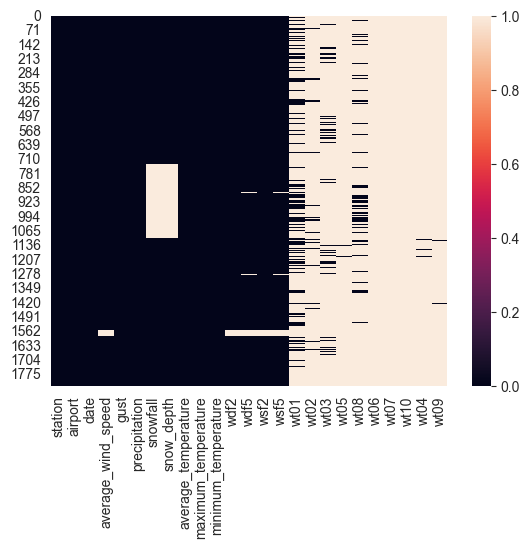

In [42]:
# null entries

# visual display
sns.heatmap(weather_df.isna())

# column names with null entries
weather_df_null_columns = []
for column in weather_df.columns:
    if weather_df[column].isna().any():
        print(f"Column {column} contains {weather_df[column].isna().sum()} null entries")
        weather_df_null_columns.append(column)

First, it is important to make a distinction between the columns with null entries that are meant to represent zero or lack of a feature, and the nulls that are genuine null entries due to some error in issues. We can easily say that all the weather type columns and gust column have null entries that should be zero. Now we're left with two main cluster of null entries that we need to understand. The lack of snow depth and snowfall data between 700 and 1000, and the thirty or so missing entries of wind data around 1550. Let us first handle the null entries which are meant to be zeros.

In [43]:
# handling initial null entries
first_weather_nulls = ['gust','wt01','wt02','wt03','wt04','wt05','wt06','wt07','wt08','wt09','wt10']
for column in first_weather_nulls:
    weather_df[column] = weather_df[column].fillna(0)

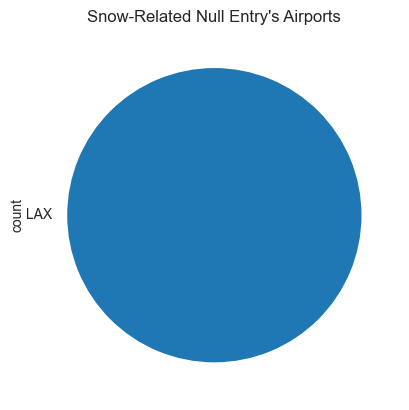

In [44]:
# visualizing snow-related null entries
snow_null_df = weather_df[(weather_df['snow_depth'].isna()) | (weather_df['snow_depth'].isna())]

# plotting the airport that contains all our nulls
snow_null_df['airport'].value_counts().plot(kind='pie')
plt.title("Snow-Related Null Entry's Airports")
plt.show()

After examining the snow null entries, I have found that it is due to the fact that despite requesting the data for snow at LAX, those columns were not included in our CSV file, which means that the online data tool found no data for snow in LAX during the year of 2024. This does not mean there is no data, but it means that there was no snow during the entire year, as proved through double-checking this fact online. Thus, we can safely say that all the null entries are zero.

In [45]:
# fixing the snow-related null entries
weather_df['snow_depth'] = weather_df['snow_depth'].fillna(0)
weather_df['snowfall'] = weather_df['snowfall'].fillna(0)

Now, let us try to find any patterns in the final null entries left related to wind data.

In [46]:
weather_df[weather_df.isna().any(axis=1)]

,station,airport,date,average_wind_speed,gust,precipitation,snowfall,snow_depth,average_temperature,maximum_temperature,...,wt01,wt02,wt03,wt05,wt08,wt06,wt07,wt10,wt04,wt09
838,USW00023174,LAX,2024-04-16,6.71,1,0.00,0.0,0.0,59,72,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
874,USW00023174,LAX,2024-05-22,7.16,1,0.00,0.0,0.0,60,67,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
881,USW00023174,LAX,2024-05-29,7.16,1,0.00,0.0,0.0,60,67,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
891,USW00023174,LAX,2024-06-08,7.83,1,0.00,0.0,0.0,64,69,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
892,USW00023174,LAX,2024-06-09,8.50,1,0.00,0.0,0.0,63,70,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1001,USW00023174,LAX,2024-09-26,NaN,1,0.00,0.0,0.0,64,70,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1280,USW00094846,ORD,2024-07-01,7.38,1,0.00,0.0,0.0,65,75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1555,USW00094789,JFK,2024-04-01,NaN,1,0.01,0.0,0.0,51,53,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1556,USW00094789,JFK,2024-04-02,NaN,1,1.02,0.0,0.0,46,48,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1557,USW00094789,JFK,2024-04-03,NaN,1,1.22,0.0,0.0,43,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We have found three kinds of null entries in this data.

1- 5 missing LAX entries and 1 mising ORD entry with no data on 5-second wind speed or direction <br>
2- 1 missing LAX entry of the average wind speed <br>
3- Missing wind information in JFK for the month of April <br>

My assumption is that all of these null entries are issues with data entry or a malfunction in the devices which are meant to capture data. For the first two, I will fill them by using the average of the month it is in. For the wind information of April out of JFK, we find a serious problem. We can either plug in the wind information of April 2025, but that might make the modeling inaccurate. Let us instead see how many flights we would remove from our dataset any flights that took off from JFK on these days.

In [47]:
# checking if the nulls are significant to our dataset
print("The percentage of flights that left out of JFK in April is equal to: ")
print(f"{(len(all_airports_df[(all_airports_df['origin'] == 2) & (all_airports_df['month'] == 4)])/len(all_airports_df))*100:.2f}%")

The percentage of flights that left out of JFK in April is equal to: 
0.74%


Since it is a small amount of data, we will drop them in both the weather column and the original flights' data.

In [48]:
# dropping the data from our weather data
weather_df = weather_df.drop(
    weather_df[
        (weather_df['date'].between('2024-04-01','2024-04-29'))
        &
        (weather_df['airport'] == 'JFK')
    ].index
)

# dropping the data from our flights df
all_airports_df = all_airports_df.drop(
    all_airports_df[
        (all_airports_df['date'].between('2024-04-01','2024-04-29'))
         &
        (all_airports_df['origin'] == 2)
    ].index
)

Now, we can fill the 5 nulls left manually. For each entry, I'll calculate the median based on two weeks' worth of data, the week before the missing data and the week after.

In [49]:
# fixing the first four LAX null entry

# number one
# calculating medians
temp_wdf5 = weather_df[
    (weather_df['date'].between('2024-04-09','2024-04-23'))
    &
    (weather_df['airport'] == 'LAX')
]['wdf5'].median()

temp_wsf5 = weather_df[
    (weather_df['date'].between('2024-05-15','2024-05-29'))
    &
    (weather_df['airport'] == 'LAX')
]['wsf5'].median()

# assigning medians
weather_df.loc[838,'wdf5'] = temp_wdf5
weather_df.loc[838,'wsf5'] = temp_wsf5
# number two
# calculating medians
temp_wdf5 = weather_df[
    (weather_df['date'].between('2024-05-15','2024-05-29'))
    &
    (weather_df['airport'] == 'LAX')
]['wdf5'].median()

temp_wsf5 = weather_df[
    (weather_df['date'].between('2024-05-15','2024-05-29'))
    &
    (weather_df['airport'] == 'LAX')
]['wsf5'].median()

# assigning medians
weather_df.loc[874,'wdf5'] = temp_wdf5
weather_df.loc[874,'wsf5'] = temp_wsf5

# number three
# calculating medians
temp_wdf5 = weather_df[
    (weather_df['date'].between('2024-05-22','2024-06-05'))
    &
    (weather_df['airport'] == 'LAX')
]['wdf5'].median()

temp_wsf5 = weather_df[
    (weather_df['date'].between('2024-05-22','2024-06-05'))
    &
    (weather_df['airport'] == 'LAX')
]['wsf5'].median()

# assigning medians
weather_df.loc[881,'wdf5'] = temp_wdf5
weather_df.loc[881,'wsf5'] = temp_wsf5

# number four and five
# calculating medians
temp_wdf5 = weather_df[
    (weather_df['date'].between('2024-06-01','2024-06-16'))
    &
    (weather_df['airport'] == 'LAX')
]['wdf5'].median()

temp_wsf5 = weather_df[
    (weather_df['date'].between('2024-06-01','2024-06-16'))
    &
    (weather_df['airport'] == 'LAX')
]['wsf5'].median()

# assigning medians
weather_df.loc[891,'wdf5'] = temp_wdf5
weather_df.loc[891,'wsf5'] = temp_wsf5
weather_df.loc[892,'wdf5'] = temp_wdf5
weather_df.loc[892,'wsf5'] = temp_wsf5

# fixing the odd LAX null entry

# calculating median
temp_mean = weather_df[
    (weather_df['date'].between('2024-09-19','2024-10-03'))
    &
    (weather_df['airport'] == 'LAX')
]['average_wind_speed'].median()

# assigning median
weather_df.loc[1001,'average_wind_speed'] = temp_mean

# fixing the odd ORD null entry

# calculating medians
temp_wdf5 = weather_df[
    (weather_df['date'].between('2024-06-24','2024-07-08'))
    &
    (weather_df['airport'] == 'ORD')
]['wdf5'].median()

temp_wsf5 = weather_df[
    (weather_df['date'].between('2024-06-24','2024-07-08'))
    &
    (weather_df['airport'] == 'ORD')
]['wsf5'].median()

# assigning medians
weather_df.loc[1280,'wdf5'] = temp_wdf5
weather_df.loc[1280,'wsf5'] = temp_wsf5

Now that all the null entries have been dealt with, it is time to clean up the columns by assigning the correct types to them and encoding any that need encoding, as well as dropping any useless ones. We will do all of this in preparation for outlier analysis.

In [50]:
# grouping the columns according to their type
weather_float_columns = [
    'average_wind_speed',
    'precipitation',
    'snowfall',
    'snow_depth',
    'average_temperature',
    'maximum_temperature',
    'minimum_temperature',
    'wsf2',
    'wsf5',
]

weather_encoded_boolean_columns = [
    'gust',
    'wt01',
    'wt02',
    'wt03',
    'wt04',
    'wt05',
    'wt06',
    'wt07',
    'wt08',
    'wt09',
    'wt10',
]

weather_encoded_string_columns = [
    'airport'
]

weather_int_columns = [
    'wdf2',
    'wdf5'
]

# changing data types for columns
# floats
for column in weather_float_columns:
    weather_df[column] = weather_df[column].astype(float)

# encoded booleans
for column in weather_encoded_boolean_columns:
    weather_df[column] = weather_df[column].astype(int)

# integers
for column in weather_int_columns:
    weather_df[column] = weather_df[column].astype(int)

# datetime
weather_df['date'] = pd.to_datetime(weather_df['date'], format='%Y-%m-%d')
weather_df['date'] = weather_df['date'].dt.strftime('%m/%d/%Y')

Now we can begin to work on our outlier handling.

Analysis of average_wind_speed:
The number of outliers based on the IQR method is 44, which accounts for 0.02% of the data
The percentiles were as follows:
25th percentile: 6.71
50th percentile: 8.5
75th percentile: 10.96
85th percentile: 12.53
90th percentile: 13.65
95th percentile: 15.43
97th percentile: 16.55
99th percentile: 19.69
The highest value in the outliers is 26.62


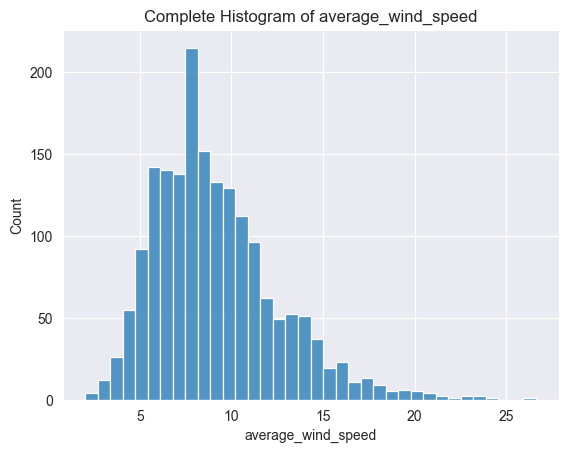

Analysis of precipitation:
The number of outliers based on the IQR method is 450, which accounts for 0.25% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
85th percentile: 0.09
90th percentile: 0.24
95th percentile: 0.57
97th percentile: 0.82
99th percentile: 1.6
The highest value in the outliers is 4.32


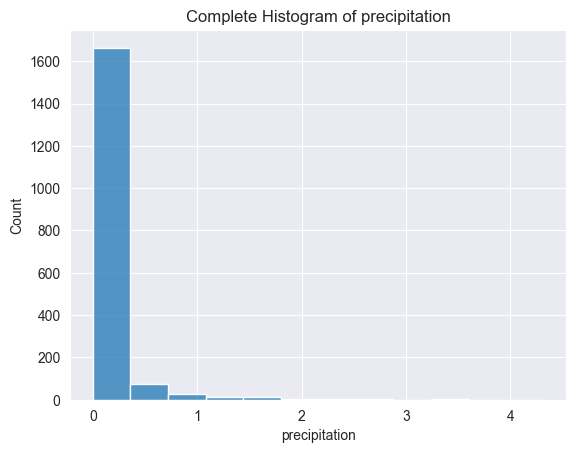

Analysis of snowfall:
The number of outliers based on the IQR method is 48, which accounts for 0.03% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
85th percentile: 0.0
90th percentile: 0.0
95th percentile: 0.0
97th percentile: 0.0
99th percentile: 2.2
The highest value in the outliers is 9.3


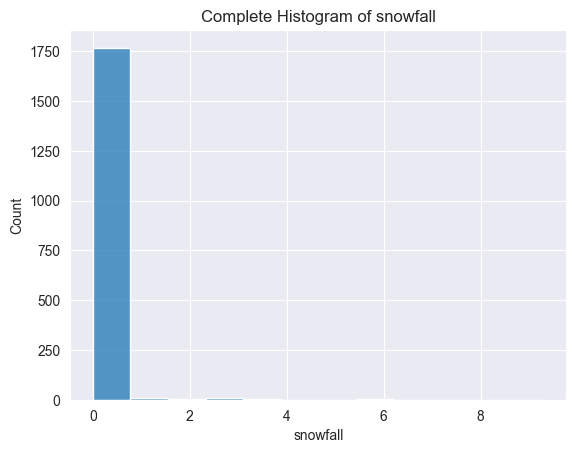

Analysis of snow_depth:
The number of outliers based on the IQR method is 66, which accounts for 0.04% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
85th percentile: 0.0
90th percentile: 0.0
95th percentile: 0.0
97th percentile: 1.2
99th percentile: 3.9
The highest value in the outliers is 13.0


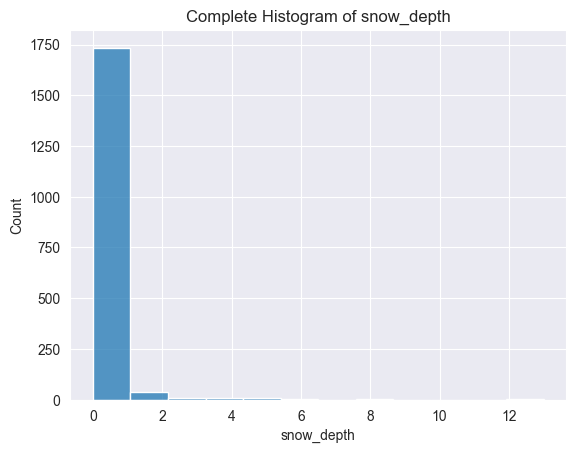

Analysis of average_temperature:
The number of outliers based on the IQR method is 0, which accounts for 0.00% of the data
The percentiles were as follows:
25th percentile: 48.0
50th percentile: 61.0
75th percentile: 71.0
85th percentile: 75.0
90th percentile: 77.0
95th percentile: 80.0
97th percentile: 82.0
99th percentile: 85.0
The highest value in the outliers is 89.0


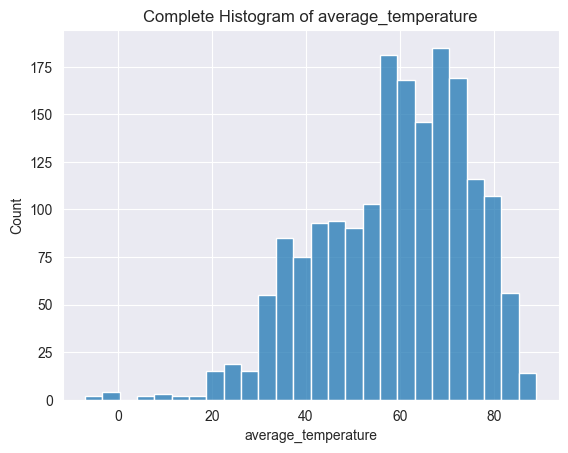

Analysis of maximum_temperature:
The number of outliers based on the IQR method is 0, which accounts for 0.00% of the data
The percentiles were as follows:
25th percentile: 58.0
50th percentile: 70.0
75th percentile: 81.0
85th percentile: 86.0
90th percentile: 89.0
95th percentile: 93.0
97th percentile: 95.0
99th percentile: 98.0
The highest value in the outliers is 102.0


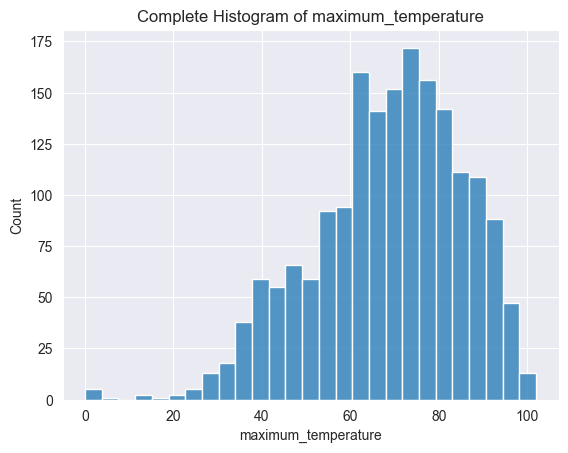

Analysis of minimum_temperature:
The number of outliers based on the IQR method is 0, which accounts for 0.00% of the data
The percentiles were as follows:
25th percentile: 38.0
50th percentile: 53.0
75th percentile: 62.0
85th percentile: 66.0
90th percentile: 69.0
95th percentile: 72.0
97th percentile: 74.0
99th percentile: 76.0
The highest value in the outliers is 79.0


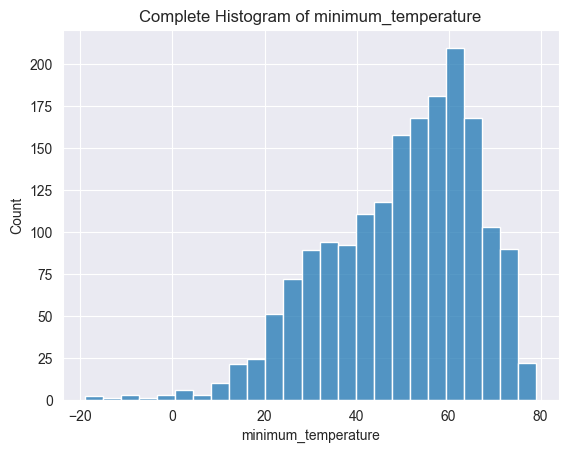

Analysis of wsf2:
The number of outliers based on the IQR method is 75, which accounts for 0.04% of the data
The percentiles were as follows:
25th percentile: 15.0
50th percentile: 18.1
75th percentile: 23.0
85th percentile: 25.9
90th percentile: 29.1
95th percentile: 33.1
97th percentile: 36.0
99th percentile: 38.9
The highest value in the outliers is 45.0


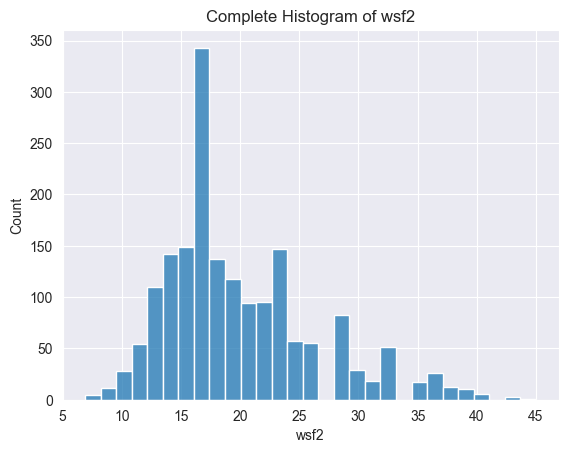

Analysis of wsf5:
The number of outliers based on the IQR method is 51, which accounts for 0.03% of the data
The percentiles were as follows:
25th percentile: 21.0
50th percentile: 25.1
75th percentile: 32.0
85th percentile: 36.9
90th percentile: 40.0
95th percentile: 46.1
97th percentile: 48.1
99th percentile: 53.9
The highest value in the outliers is 74.9


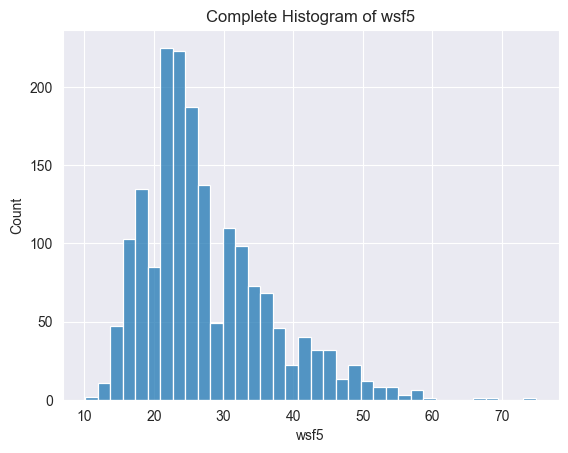

In [51]:
for column in weather_float_columns:
    # iqr calculations
    q3 = weather_df[column].quantile(0.75)
    q2 = weather_df[column].quantile(0.50)
    q1 = weather_df[column].quantile(0.25)
    iqr = q3 - q1
    upper_limit = q3 + 1.5*iqr
    iqr_outlier_count = len(weather_df[weather_df[column] > upper_limit])
    iqr_outlier_count_ratio = iqr_outlier_count / len(weather_df)
    # displaying data
    print(f"Analysis of {column}:")
    print(f"The number of outliers based on the IQR method is {iqr_outlier_count}, which accounts for {iqr_outlier_count_ratio:.2f}% of the data")
    print("The percentiles were as follows:\n"
          f"25th percentile: {q1}\n"
          f"50th percentile: {q2}\n"
          f"75th percentile: {q3}\n"
          f"85th percentile: {weather_df[column].quantile(0.85)}\n"
          f"90th percentile: {weather_df[column].quantile(0.90)}\n"
          f"95th percentile: {weather_df[column].quantile(0.95)}\n"
          f"97th percentile: {weather_df[column].quantile(0.97)}\n"
          f"99th percentile: {weather_df[column].quantile(0.99)}\n"
          f"The highest value in the outliers is {weather_df[column].max()}"
          )
    sns.histplot(data=weather_df[column])
    plt.title(f"Complete Histogram of {column}")
    plt.show()

Since the outliers are incredibly rare, I do not think they are worth handling, as this way we can keep the accuracy of the data while not having any outliers distorting the data. It is now time for feature engineering.

## C- Feature Engineering

Now that we are done with data cleaning, we can begin working on new columns based on this data. We will:
* Add any columns that I believe to be useful in understanding and modeling the data
* Drop any columns that are not useful or might undermine our modeling
* Encode and scale our data as needed

I will add the following columns, with any needed justification written below each:<br>

1- sin/cos_circular_wdf2 (Float) <br>
These two columns measure the direction of the strongest two-minute wind breeze using circular measurements.

2- sin/cos_circular_wdf5 (Float) <br>
These two columns measure the direction of the strongest five-second wind breeze using circular measurements.

3- runway_direction_1 (Integer) <br>
One of the two directions that parallel runways can take off from, measured in degrees. If the parallel runway is horizontal, then this direction will be the eastern side. If it is horizontal, it will be from the northern side. If the airport does not have parallel runways only, then this direction will be given a -1.

4- runway_direction_2 (Integer) <br>
One of the two directions that parallel runways can take off from, measured in degrees. If the parallel runway is horizontal, then this direction will be the western side. If it is horizontal, it will be from the southern side. If the airport does not have parallel runways only, then this direction will be given a -1.

5- wind_runway_angle (Boolean) <br>
This measures the smallest possible angle between the runway and the average wind on that day. This is based on gathering the angle of the wind with the runway, and then measuring which direction of the runway will have the least amount of crosswind, and then using that angle as our metric. Crosswinds are winds that do not follow the directions of the runway(s). If an airport has non-parallel runways and is thus not affected by crosswinds, then the value of this will be -1. We will use wdf2 for our measurement for crosswinds, since it is more consistent with how much longer it is.

6- has_high_winds (Boolean) <br>
This measures whether the average wind speed was higher than 20 knots or not.

7- has_precipitation (Boolean) <br>
Since precipitation is rare, this column measures it as a boolean.

8- has_snowfall (Boolean) <br>
This column measures snowfall as a boolean, since it is very rare and most of the entries are zero.

<br>
<br>
The reason that airports with parallel runways get two directions is because any singular physical runway equates to two runways pilots can use. If you have a runway with two end points, A and B, then you can place your plane at A and take off in the direction of B, or you can put your plane at B and take off in the direction of A. This is why there needs to be two runway directions, as to understand the two directions planes usually take off from.

We will first begin by creating our new columns, and encoding them as we go along, and removing any unnecessary columns. Each code cell will add a different column or set of columns.

In [52]:
# creating new columns

# circular wdf2
weather_df['sin_circular_wdf2'], weather_df['cos_circular_wdf2']= make_time_cyclical(weather_df['wdf2'],'year')
weather_int_columns.append('sin_circular_wdf2')

# circular wdf5
weather_df['sin_circular_wdf5'], weather_df['cos_circular_wdf5']= make_time_cyclical(weather_df['wdf5'],'year')
weather_int_columns.append('sin_circular_wdf5')

In [53]:
# mapping the runway directions, cities without parallel runways get -1
runway_direction_1_mapping = {
    'ATL': 95, # atlanta
    'LAX': 70, # los angeles
    'DEN': -1, # denver
    'JFK': -1, # new york
    'ORD': -1  # chicago
}
runway_direction_2_mapping = {
    'ATL': 275, # atlanta
    'LAX': 250, # los angeles
    'DEN': -1, # denver
    'JFK': -1, # new york
    'ORD': -1  # chicago
}

# runway direction
weather_df['runway_direction_1'] = weather_df['airport'].map(runway_direction_1_mapping)
weather_df['runway_direction_2'] = weather_df['airport'].map(runway_direction_2_mapping)
weather_int_columns.append('runway_direction_1')
weather_int_columns.append('runway_direction_2')

In [54]:
# crosswinds columns

# atlanta
atl_crosswinds_df = weather_df[weather_df['airport'] == 'ATL']

# creating angle for direction 1 of the runway
atl_crosswinds_angle_1a = abs(atl_crosswinds_df['runway_direction_1'] - atl_crosswinds_df['wdf2'])
atl_crosswinds_angle_1b = 360 - atl_crosswinds_angle_1a
atl_crosswinds_angle_1 = np.minimum(atl_crosswinds_angle_1a, atl_crosswinds_angle_1b)

# creating angle for direction 2 of the runway
atl_crosswinds_angle_2a = abs(atl_crosswinds_df['runway_direction_2'] - atl_crosswinds_df['wdf2'])
atl_crosswinds_angle_2b = 360 - atl_crosswinds_angle_2a
atl_crosswinds_angle_2 = np.minimum(atl_crosswinds_angle_2a, atl_crosswinds_angle_2b)

# picking the smallest angle
atl_crosswinds = np.minimum(atl_crosswinds_angle_1, atl_crosswinds_angle_2)


# los angeles
lax_crosswinds_df = weather_df[weather_df['airport'] == 'LAX']

# creating angle for direction 1 of the runway
lax_crosswinds_angle_1a = abs(lax_crosswinds_df['runway_direction_1'] - lax_crosswinds_df['wdf2'])
lax_crosswinds_angle_1b = 360 - lax_crosswinds_angle_1a
lax_crosswinds_angle_1 = np.minimum(lax_crosswinds_angle_1a, lax_crosswinds_angle_1b)

# creating angle for direction 2 of the runway
lax_crosswinds_angle_2a = abs(lax_crosswinds_df['runway_direction_2'] - lax_crosswinds_df['wdf2'])
lax_crosswinds_angle_2b = 360 - lax_crosswinds_angle_2a
lax_crosswinds_angle_2 = np.minimum(lax_crosswinds_angle_2a, lax_crosswinds_angle_2b)

# picking the smallest angle
lax_crosswinds = np.minimum(lax_crosswinds_angle_1, lax_crosswinds_angle_2)


# denver
den_crosswinds_df = weather_df[weather_df['airport'] == 'DEN']
den_crosswinds = den_crosswinds_df.assign(temp=-1)['temp']

# new york
jfk_crosswinds_df = weather_df[weather_df['airport'] == 'JFK']
jfk_crosswinds = jfk_crosswinds_df.assign(temp=-1)['temp']

# chicago
ord_crosswinds_df = weather_df[weather_df['airport'] == 'ORD']
ord_crosswinds = ord_crosswinds_df.assign(temp=-1)['temp']

# combining all airports' crosswinds to one column
weather_df['wind_runway_angle'] = pd.concat([atl_crosswinds,lax_crosswinds,den_crosswinds,jfk_crosswinds,ord_crosswinds],axis=0)
weather_df['wind_runway_angle'] = weather_df['wind_runway_angle'].astype(int)
weather_int_columns.append('wind_runway_angle')

In [55]:
# has high winds
weather_df['has_high_winds'] = weather_df['average_wind_speed'] >= 20
weather_df['has_high_winds'] = weather_df['has_high_winds'].map({True:1,False:0})
weather_encoded_boolean_columns.append('has_high_winds')

# has precipitation
weather_df['has_precipitation'] = weather_df['precipitation'] > 0
weather_df['has_precipitation'] = weather_df['has_precipitation'].map({True:1,False:0})
weather_encoded_boolean_columns.append('has_precipitation')

# has snowfall
weather_df['has_snowfall'] = weather_df['snowfall'] > 0
weather_df['has_snowfall'] = weather_df['has_snowfall'].map({True:1,False:0})
weather_encoded_boolean_columns.append('has_snowfall')

In [56]:
# removing unnecessary columns
if 'station' in weather_df.columns:
    weather_df = weather_df.drop(columns='station')

Now, we can encode and scale our columns. We will scale all numerical (or float) columns after all datasets are combined. We will encode any categorical columns. We will additionally change the date column to be in datetime type.

In [57]:
# encoding categorical columns
weather_df['airport'] = weather_df['airport'].map(origin_mapping)

# changing date column to datetype
weather_df['date'] = pd.to_datetime(weather_df['date'], format='%m/%d/%Y').dt.strftime('%Y-%m-%d')

## 3- Daily Air traffic Volumes
### Description:
This file will contain the daily number of aircraft operating out of our five airports in 2024. It is mainly aimed to target NAS disruptions. <br>
* It will primarily be divided into aircraft operating under IFR (instrument flight rules) or VFR (visual flight rules). IFR is when the pilot is allowed to use visual markers and ques to operate the aircraft without requiring the usage of instruments, while VFR is when the pilot is required constant interaction with ATC and must use the instruments to determine their course of action. The flight rules allowed into an airspace are based on the class of airspace an airport is located in. According to the [ICAO class groupings](https://www.ifalpa.org/media/3392/19atsbl01-airspace-classification.pdf), all five of our airports are in Class B, which allow VFR pilots only with explicit ATC clearance based on traffic conditions and current ATC workload, so any patterns located here would be of value.
* Beyond the flight rules distinction, the data is further seperated into counting of aircraft operating. THe categories are: air carrier, air taxi, general aviation, and military. These could also offer valuable patterns regarding delays.

### Source:
The data was gathered from the Federal Aviation Administration's Operation Network (OPSNET). They have an [online tool](https://www.aspm.faa.gov/opsnet/sys/main.asp) which allows you to request this data from their database. It was all pre-packaged in one file, but it was not in CSV format due to the presence of titles and sub-columns, so I formatted it manually on Microsoft Excel, and that is the file we will be used. The file 'original_air_traffic_data' is the unedited one and in present in the relevant folder for your convenience.

The columns of this data is as follows:

- Date <br>
This shows the day that experienced the given traffic numbers

- Airport <br>
The airport that this air traffic was flying out of

- IFR Air Carrier <br>
This column shows the number of commercial airline carrier planes flown using the IFR flight rules.

- IFR Air Taxi <br>
This column shows the number of commercial air taxi planes flown using the IFR flight rules.

- IFR General Aviation <br>
This column shows the number of unspecified general airplanes flown using the IFR flight rules.

- IFR Military <br>
This column shows the number of military planes flown using the IFR flight rules.

- IFR Total <br>
This column shows the total number of planes flown using IFR flight rules, regardless of purpose.

- VFR Air Carrier <br>
This column shows the number of commercial airline carrier planes flown using the VFR flight rules.

- VFR Air Taxi <br>
This column shows the number of commercial air taxi planes flown using the VFR flight rules.

- VFR General Aviation <br>
This column shows the number of unspecified general airplanes flown using the VFR flight rules.

- VFR Military <br>
This column shows the number of military planes flown using the VFR flight rules.

- VFR Total <br>
This column shows the total number of planes flown using VFR flight rules, regardless of purpose.

- Total Air Carrier <br>
This column shows the total number of commercial airline carrier planes flown.

- Total Air Taxi <br>
This column shows the total number of commercial air taxis planes flown.

- Total General Aviation <br>
This column shows the total number of unspecified general airplanes flown.

- Total Military <br>
This column shows the total number of military planes flown.

- Total Daily Activity <br>
This column is the most important one, it is the number of all the planes that flew out of the airport on a given day.


## A- Data Collection

In this section, we will:
  * Read our file into its own DataFrame.

In [58]:
# creating our air traffic df
air_traffic_df = pd.read_csv('/flight_delay_model_data/data_preprocessing/raw_air_traffic_data/raw_air_traffic_data.csv')

## B- Data Cleaning

With our file now ready, we will begin to:
* Clean column names and rename complicated ones
* Clean column datatypes
* Check for null entries and handle them

In [59]:
# cleaning column names
for column in air_traffic_df.columns:
    new_column_name = column.strip().replace(' ', '_').lower()
    air_traffic_df.rename(columns={column: new_column_name}, inplace=True)

# renaming columns
air_traffic_df.rename(columns= {
    "ifr_air_carrier":"ifr_carrier",
    "vfr_air_carrier":"vfr_carrier",
    "ifr_general_aviation":"ifr_other",
    "vfr_general_aviation":"vfr_other",
    "ifr_air_taxi":"ifr_taxi",
    "vfr_air_taxi":"vfr_taxi",
    "total_air_carrier":"total_carrier",
    "total_general_aviation":"total_other",
    "total_air_taxi":"total_taxi",
    "total_daily_activity":"total_traffic"
    },
inplace=True)

All the columns are in the type that we want them to be, which is integers for all numerical columns and objects for the airport and the data. We are now left with null entry handling. Let us check for null entries.

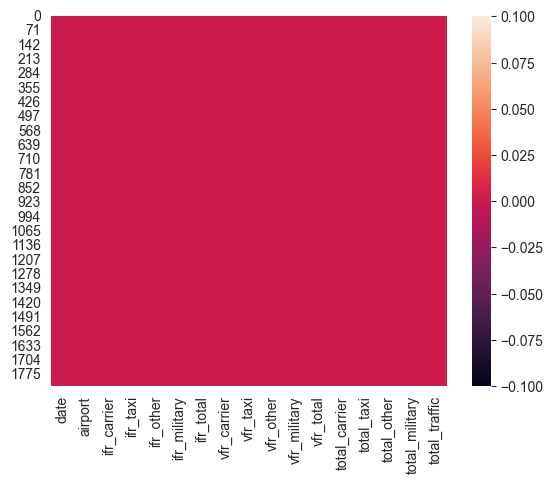

In [60]:
# null entries

# visual display
sns.heatmap(air_traffic_df.isna())

# column names with null entries
air_traffic_null_columns = []
for column in air_traffic_df.columns:
    if air_traffic_df[column].isna().any():
        print(f"Column {column} contains {air_traffic_df[column].isna().sum()} null entries")
        air_traffic_null_columns.append(column)

Since there are no null entries in our data, we can skip null handling entirely and go directly towards outlier handling.

Analysis of ifr_carrier:
The number of outliers based on the IQR method is 0, which accounts for 0.00% of the data
The percentiles were as follows:
25th percentile: 1409.25
50th percentile: 1621.0
75th percentile: 1870.75
85th percentile: 2021.6499999999999
90th percentile: 2163.0
95th percentile: 2279.0
97th percentile: 2321.0
99th percentile: 2359.13
The highest value in the outliers is 2408


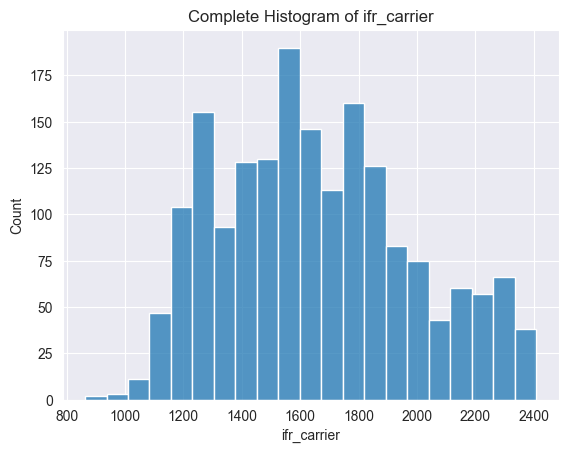

Analysis of ifr_taxi:
The number of outliers based on the IQR method is 0, which accounts for 0.00% of the data
The percentiles were as follows:
25th percentile: 20.0
50th percentile: 56.0
75th percentile: 238.0
85th percentile: 312.0
90th percentile: 353.0
95th percentile: 383.0
97th percentile: 393.0
99th percentile: 401.71000000000004
The highest value in the outliers is 418


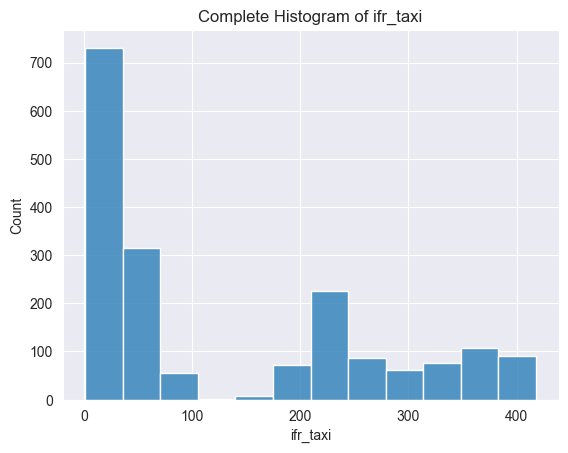

Analysis of ifr_other:
The number of outliers based on the IQR method is 132, which accounts for 0.07% of the data
The percentiles were as follows:
25th percentile: 6.0
50th percentile: 11.0
75th percentile: 18.0
85th percentile: 28.0
90th percentile: 34.0
95th percentile: 39.0
97th percentile: 43.0
99th percentile: 50.710000000000036
The highest value in the outliers is 69


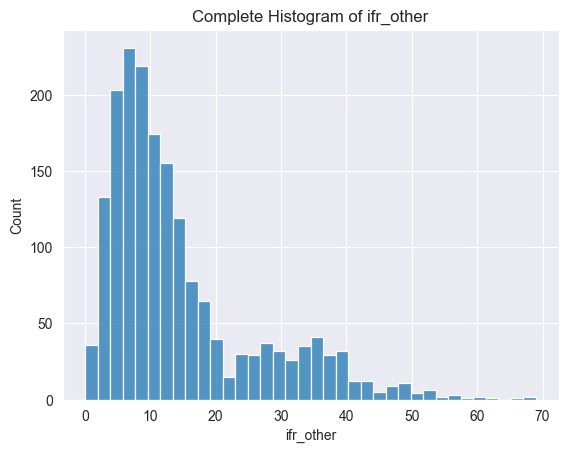

Analysis of ifr_military:
The number of outliers based on the IQR method is 436, which accounts for 0.24% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
85th percentile: 1.0
90th percentile: 2.0
95th percentile: 3.0
97th percentile: 4.0
99th percentile: 7.710000000000036
The highest value in the outliers is 17


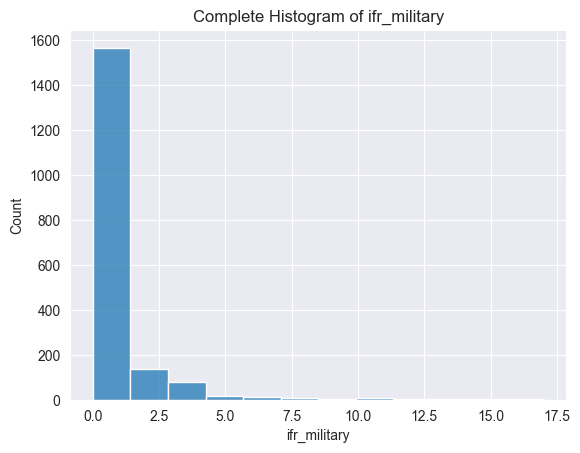

Analysis of ifr_total:
The number of outliers based on the IQR method is 0, which accounts for 0.00% of the data
The percentiles were as follows:
25th percentile: 1507.0
50th percentile: 1848.0
75th percentile: 2120.75
85th percentile: 2235.6499999999996
90th percentile: 2301.1000000000004
95th percentile: 2359.0
97th percentile: 2392.0
99th percentile: 2428.71
The highest value in the outliers is 2478


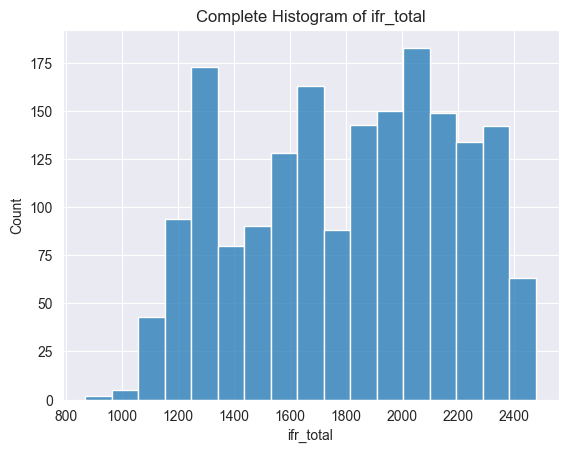

Analysis of vfr_carrier:
The number of outliers based on the IQR method is 43, which accounts for 0.02% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
85th percentile: 0.0
90th percentile: 0.0
95th percentile: 0.0
97th percentile: 0.0
99th percentile: 1.0
The highest value in the outliers is 3


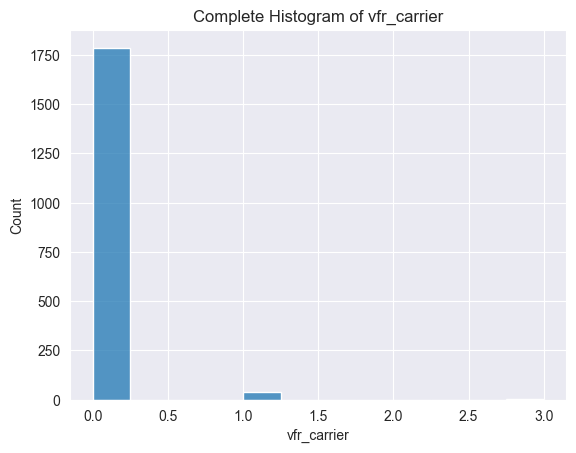

Analysis of vfr_taxi:
The number of outliers based on the IQR method is 375, which accounts for 0.20% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
85th percentile: 2.0
90th percentile: 4.0
95th percentile: 5.0
97th percentile: 6.0
99th percentile: 8.0
The highest value in the outliers is 23


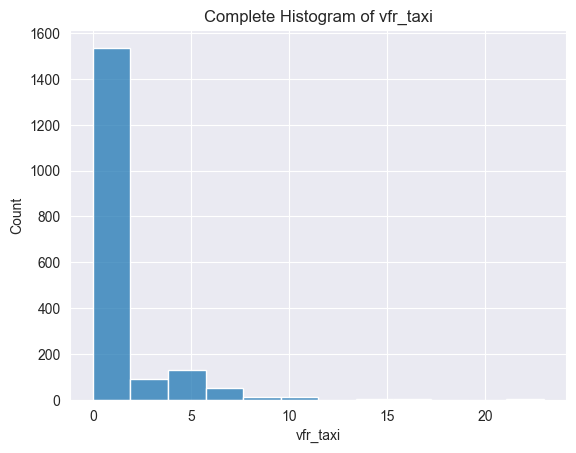

Analysis of vfr_other:
The number of outliers based on the IQR method is 268, which accounts for 0.15% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 1.0
75th percentile: 7.0
85th percentile: 16.0
90th percentile: 32.0
95th percentile: 46.0
97th percentile: 50.12999999999988
99th percentile: 60.0
The highest value in the outliers is 70


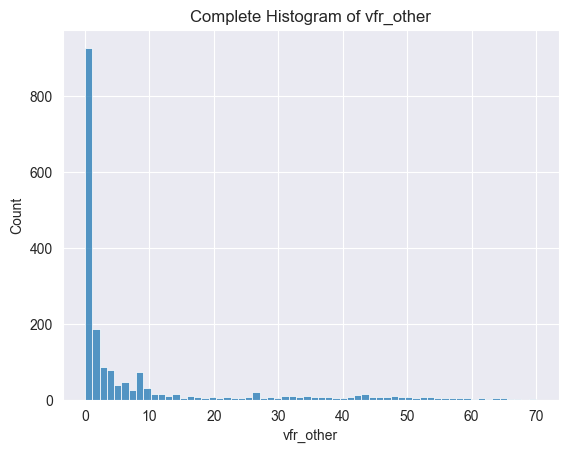

Analysis of vfr_military:
The number of outliers based on the IQR method is 183, which accounts for 0.10% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
85th percentile: 0.0
90th percentile: 0.10000000000013642
95th percentile: 1.0
97th percentile: 2.0
99th percentile: 3.0
The highest value in the outliers is 6


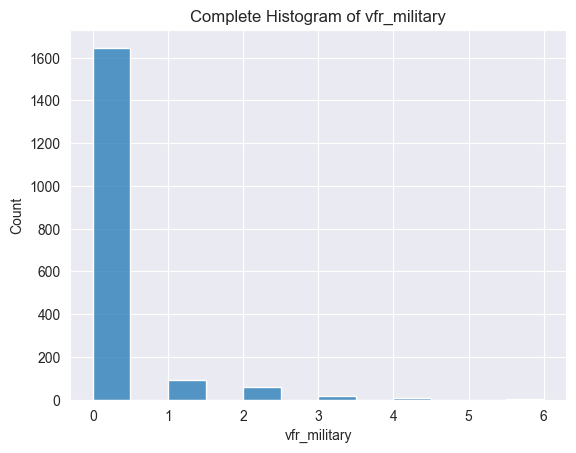

Analysis of vfr_total:
The number of outliers based on the IQR method is 266, which accounts for 0.15% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 2.0
75th percentile: 8.0
85th percentile: 18.0
90th percentile: 35.0
95th percentile: 50.0
97th percentile: 58.0
99th percentile: 67.71000000000004
The highest value in the outliers is 76


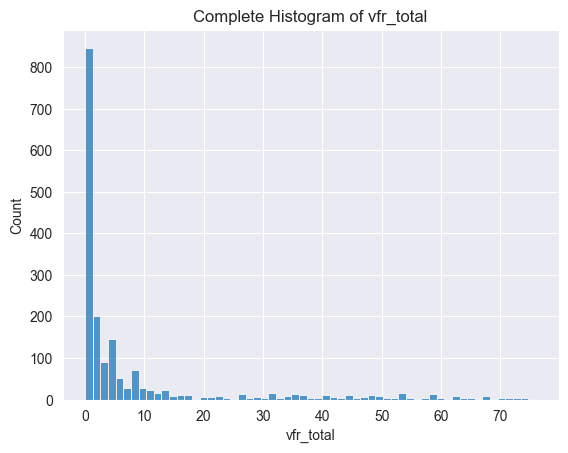

Analysis of total_carrier:
The number of outliers based on the IQR method is 0, which accounts for 0.00% of the data
The percentiles were as follows:
25th percentile: 1409.25
50th percentile: 1621.5
75th percentile: 1870.75
85th percentile: 2021.6499999999999
90th percentile: 2163.0
95th percentile: 2279.0
97th percentile: 2321.0
99th percentile: 2359.13
The highest value in the outliers is 2408


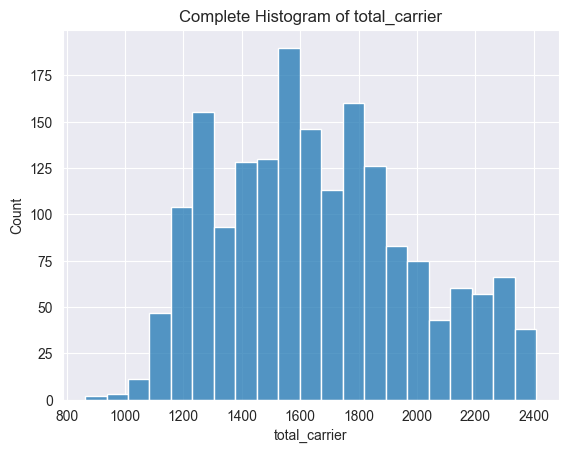

Analysis of total_taxi:
The number of outliers based on the IQR method is 0, which accounts for 0.00% of the data
The percentiles were as follows:
25th percentile: 22.0
50th percentile: 56.0
75th percentile: 238.0
85th percentile: 312.0
90th percentile: 353.0
95th percentile: 383.0
97th percentile: 393.0
99th percentile: 403.0
The highest value in the outliers is 418


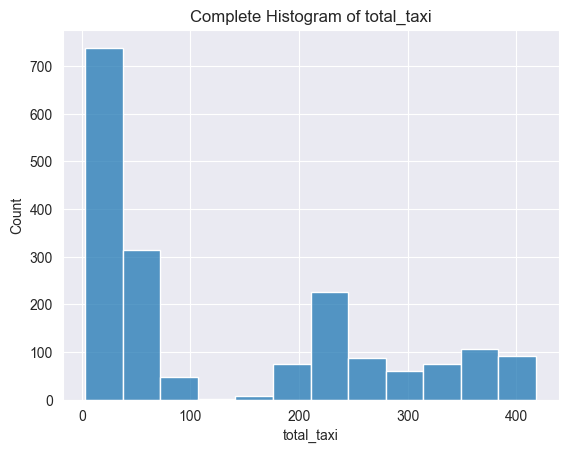

Analysis of total_other:
The number of outliers based on the IQR method is 18, which accounts for 0.01% of the data
The percentiles were as follows:
25th percentile: 9.0
50th percentile: 17.0
75th percentile: 33.0
85th percentile: 40.0
90th percentile: 47.0
95th percentile: 55.0
97th percentile: 60.0
99th percentile: 69.0
The highest value in the outliers is 85


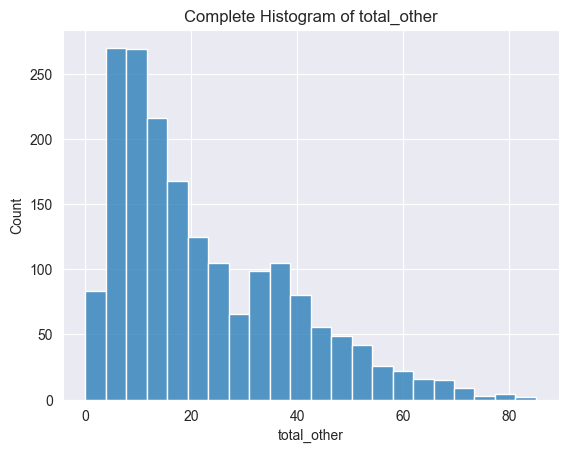

Analysis of total_military:
The number of outliers based on the IQR method is 174, which accounts for 0.10% of the data
The percentiles were as follows:
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 1.0
85th percentile: 2.0
90th percentile: 2.0
95th percentile: 4.0
97th percentile: 5.0
99th percentile: 8.0
The highest value in the outliers is 19


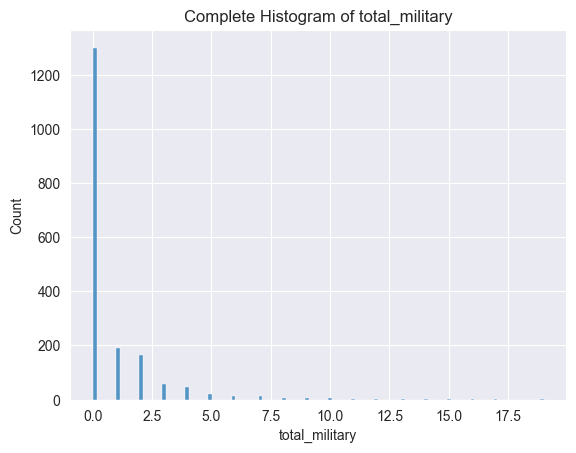

Analysis of total_traffic:
The number of outliers based on the IQR method is 0, which accounts for 0.00% of the data
The percentiles were as follows:
25th percentile: 1508.0
50th percentile: 1848.5
75th percentile: 2121.75
85th percentile: 2240.6499999999996
90th percentile: 2306.1000000000004
95th percentile: 2365.1
97th percentile: 2395.13
99th percentile: 2431.42
The highest value in the outliers is 2480


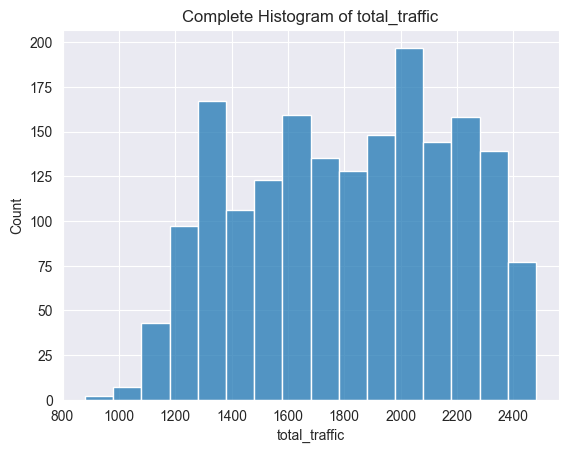

In [61]:
# outlier handling

for column in air_traffic_df:
    if column == 'date' or column == 'airport':
        continue
    # iqr calculations
    q3 = air_traffic_df[column].quantile(0.75)
    q2 = air_traffic_df[column].quantile(0.50)
    q1 = air_traffic_df[column].quantile(0.25)
    iqr = q3 - q1
    upper_limit = q3 + 1.5*iqr
    iqr_outlier_count = len(air_traffic_df[air_traffic_df[column] > upper_limit])
    iqr_outlier_count_ratio = iqr_outlier_count / len(air_traffic_df)
    # displaying data
    print(f"Analysis of {column}:")
    print(f"The number of outliers based on the IQR method is {iqr_outlier_count}, which accounts for {iqr_outlier_count_ratio:.2f}% of the data")
    print("The percentiles were as follows:\n"
          f"25th percentile: {q1}\n"
          f"50th percentile: {q2}\n"
          f"75th percentile: {q3}\n"
          f"85th percentile: {air_traffic_df[column].quantile(0.85)}\n"
          f"90th percentile: {air_traffic_df[column].quantile(0.90)}\n"
          f"95th percentile: {air_traffic_df[column].quantile(0.95)}\n"
          f"97th percentile: {air_traffic_df[column].quantile(0.97)}\n"
          f"99th percentile: {air_traffic_df[column].quantile(0.99)}\n"
          f"The highest value in the outliers is {air_traffic_df[column].max()}"
          )
    sns.histplot(data=air_traffic_df[column])
    plt.title(f"Complete Histogram of {column}")
    plt.show()

As we can see, there are almost no outliers in this dataset, and the ones that do exist fall within the normal ranges of 0.30%. Thus, we can begin with feature engineering.
<br>
Due to the relative simplicity of this dataset, I have not found it necessary to conduct any further feature engineering. I will  encode the airport column to correspond to the mapping we have established across the other datasets. Additionally, the raw data does not contain the corrct dates of the first 14 days, so I will manually add the dates, and ensure that they are in the correct pandas date-type. After that, we will be done with all the work this dataset requires.

In [62]:
air_traffic_df

,date,airport,ifr_carrier,ifr_taxi,ifr_other,ifr_military,ifr_total,vfr_carrier,vfr_taxi,vfr_other,vfr_military,vfr_total,total_carrier,total_taxi,total_other,total_military,total_traffic
0,45292,ATL,1748,19,4,0,1771,0,0,0,0,0,1748,19,4,0,1771
1,45292,DEN,1661,161,5,0,1827,0,0,0,0,0,1661,161,5,0,1827
2,45292,JFK,1118,10,6,0,1134,0,0,14,0,14,1118,10,20,0,1148
3,45292,LAX,1399,76,29,0,1504,0,0,4,0,4,1399,76,33,0,1508
4,45292,ORD,1506,309,4,0,1819,0,0,1,0,1,1506,309,5,0,1820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1825,12/31/2024,ATL,1847,20,9,0,1876,0,0,2,0,2,1847,20,11,0,1878
1826,12/31/2024,DEN,1570,234,2,0,1806,0,0,0,0,0,1570,234,2,0,1806
1827,12/31/2024,JFK,1097,6,10,0,1113,0,4,14,0,18,1097,10,24,0,1131
1828,12/31/2024,LAX,1473,34,21,0,1528,0,0,0,0,0,1473,34,21,0,1528


In [63]:
# encoding categorical features
air_traffic_df['airport'] = air_traffic_df['airport'].map(origin_mapping)

# adding the correct dates
# january
air_traffic_df['date'] = air_traffic_df['date'].replace("45292","01/01/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45323","01/02/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45352","01/03/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45383","01/04/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45413","01/05/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45444","01/06/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45474","01/07/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45505","01/08/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45536","01/09/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45566","01/10/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45597","01/11/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45627","01/12/2024")

# february
air_traffic_df['date'] = air_traffic_df['date'].replace("45293","02/01/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45324","02/02/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45353","02/03/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45384","02/04/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45414","02/05/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45445","02/06/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45475","02/07/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45506","02/08/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45537","02/09/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45567","02/10/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45598","02/11/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45628","02/12/2024")

# march
air_traffic_df['date'] = air_traffic_df['date'].replace("45294","03/01/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45325","03/02/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45354","03/03/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45385","03/04/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45415","03/05/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45446","03/06/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45476","03/07/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45507","03/08/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45538","03/09/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45568","03/10/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45599","03/11/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45629","03/12/2024")

# april
air_traffic_df['date'] = air_traffic_df['date'].replace("45295","04/01/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45326","04/02/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45355","04/03/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45386","04/04/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45416","04/05/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45447","04/06/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45477","04/07/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45508","04/08/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45539","04/09/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45569","04/10/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45600","04/11/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45630","04/12/2024")

# may
air_traffic_df['date'] = air_traffic_df['date'].replace("45296","05/01/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45327","05/02/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45356","05/03/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45387","05/04/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45417","05/05/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45448","05/06/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45478","05/07/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45509","05/08/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45540","05/09/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45570","05/10/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45601","05/11/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45631","05/12/2024")

# june
air_traffic_df['date'] = air_traffic_df['date'].replace("45297","06/01/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45328","06/02/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45357","06/03/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45388","06/04/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45418","06/05/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45449","06/06/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45479","06/07/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45510","06/08/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45541","06/09/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45571","06/10/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45602","06/11/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45632","06/12/2024")

# july
air_traffic_df['date'] = air_traffic_df['date'].replace("45298","07/01/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45329","07/02/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45358","07/03/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45389","07/04/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45419","07/05/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45450","07/06/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45480","07/07/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45511","07/08/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45542","07/09/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45572","07/10/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45603","07/11/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45633","07/12/2024")

# august
air_traffic_df['date'] = air_traffic_df['date'].replace("45299","08/01/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45330","08/02/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45359","08/03/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45390","08/04/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45420","08/05/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45451","08/06/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45481","08/07/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45512","08/08/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45543","08/09/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45573","08/10/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45604","08/11/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45634","08/12/2024")

# september
air_traffic_df['date'] = air_traffic_df['date'].replace("45300","09/01/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45331","09/02/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45360","09/03/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45391","09/04/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45421","09/05/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45452","09/06/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45482","09/07/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45513","09/08/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45544","09/09/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45574","09/10/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45605","09/11/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45635","09/12/2024")

# october
air_traffic_df['date'] = air_traffic_df['date'].replace("45301","10/01/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45332","10/02/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45361","10/03/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45392","10/04/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45422","10/05/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45453","10/06/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45483","10/07/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45514","10/08/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45545","10/09/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45575","10/10/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45606","10/11/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45636","10/12/2024")

# november
air_traffic_df['date'] = air_traffic_df['date'].replace("45302","11/01/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45333","11/02/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45362","11/03/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45393","11/04/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45423","11/05/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45454","11/06/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45484","11/07/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45515","11/08/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45546","11/09/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45576","11/10/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45607","11/11/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45637","11/12/2024")

# december
air_traffic_df['date'] = air_traffic_df['date'].replace("45303","12/01/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45334","12/02/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45363","12/03/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45394","12/04/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45424","12/05/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45455","12/06/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45485","12/07/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45516","12/08/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45547","12/09/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45577","12/10/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45608","12/11/2024")
air_traffic_df['date'] = air_traffic_df['date'].replace("45638","12/12/2024")

# changing date column to datetype
air_traffic_df['date'] = pd.to_datetime(air_traffic_df['date'], format='%m/%d/%Y').dt.strftime('%Y-%m-%d')

## 4- Final Dataset
### Description:
This dataset will be a combination of the three previous datasets, and will be the dataset used in our predictive models' training and test. It will contain all the data from the flight on-time dataset, which is the cornerstone of our data, but it will also contain all data regarding that airport's weather condition on the day of departure, as well as the air traffic data from the day of the departure.

### Methodology:
Our biggest challenge is the fact that each dataset is tied to a different feature. Our initial airports dataset is tied to every flight that took place, our weather dataset is tied to the hour of the day, and the air traffic dataset is tied to the overall day. To solve this, I have decided to use the initial airport and flight dataset as our anchor, and we will plug in the information from the other two datasets based the initial one. After combining them into one dataset, we will proceed to conduct some correlation analysis between our flight data and our newly introduced features from the two new datasets to help us understand how our predictive model might work. After that, we will be done with data pre-processing for our project, and we will thus be done with this file in the project.

## A- Combining the Datasets
I will begin by creating a new dataset that will copy our flight on-time dataset, and then will proceed to add features from the other two datasets, anchored by the time and date in the flight on-time data.

In [1]:
# creating a new dataset
final_df = all_airports_df.copy()

# adding features from our two other datasets
new_features = []


NameError: name 'all_airports_df' is not defined

In [ ]:
air_traffic_df

In [ ]:
final_df